# UdaciSense: Optimized Object Recognition
## Notebook 2: Compression Techniques

 
In this notebook, you'll explore different model compression techniques to meet the requirements:
- The optimized model should be **30% smaller** than the baseline
- The optimized model should **reduce inference time by 40%**
- The optimized model should **maintain accuracy within 5%** of the baseline

You can experiment with different methods:
1. **Post-training**: Quantization, pruning, graph optimizations.
2. **In-training**: Quantization, pruning, distillation.
Optionally, you can choose to implement other techniques too.

Make sure to experiment with at least two different techniques. 
You will need to combine the selected techniques into a multi-step compression pipeline next, so make sure to select techniques that seem  promising individually but also combined.

### Step 1: Set up the environment

In [3]:
# Make sure that libraries are dynamically re-loaded if changed
get_ipython().run_line_magic('load_ext', 'autoreload')
get_ipython().run_line_magic('autoreload', '2')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# Import necessary libraries
import os
import sys
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pprint
import random
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# Ensure project root (starter-kit) is on sys.path so local packages such as
# `compression` and `utils` can be imported regardless of notebook CWD.
_cwd = Path.cwd().resolve()
_candidates = [
    _cwd,
    _cwd / "starter-kit",
    _cwd.parent,
    _cwd.parent / "starter-kit",
]
for _p in _candidates:
    if (_p / "compression").is_dir() and (_p / "utils").is_dir():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        break

from compression.post_training.pruning import prune_model
from compression.post_training.quantization import quantize_model
from compression.post_training.graph_optimization import optimize_model, verify_model_equivalence
from compression.in_training.distillation import train_with_distillation, MobileNetV3_Household_Small
from compression.in_training.pruning import train_with_pruning
from compression.in_training.quantization import train_model_qat, QuantizableMobileNetV3_Household

from utils import MAX_ALLOWED_ACCURACY_DROP, TARGET_INFERENCE_SPEEDUP,TARGET_MODEL_COMPRESSION 
from utils.data_loader import get_household_loaders, get_input_size, print_dataloader_stats, visualize_batch
from utils.model import MobileNetV3_Household, load_model, save_model, print_model_summary
from utils.visualization import plot_multiple_models_comparison
from utils.compression import (
    compare_experiments, compare_optimized_model_to_baseline, evaluate_optimized_model, list_experiments,  # For experimentation
    is_quantized  # For quantization
)

In [5]:
# Ignore PyTorch deprecation warnings
import warnings
warnings.filterwarnings("ignore", category=torch.jit.TracerWarning)
warnings.filterwarnings("ignore", category=UserWarning)  # Optional: Ignore all user warnings

In [6]:
# Check if CUDA is available
devices = ["cpu"]
if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    devices.extend([f"cuda:{i} ({torch.cuda.get_device_name(i)})" for i in range(num_devices)])
print(f"Devices available: {devices}")

Devices available: ['cpu', 'cuda:0 (Tesla T4)']


In [7]:
# Create directories for each technique
compression_types = [
    "post_training/pruning",
    "post_training/quantization",
    "post_training/graph_optimization",
    "in_training/distillation", 
    "in_training/quantization",
    "in_training/pruning",
]
for comp_type in compression_types:
    models_dir = f"../models/{comp_type}"
    models_ckp_dir = f"{models_dir}/checkpoints"
    results_dir = f"../results/{comp_type}"
    
    os.makedirs(models_ckp_dir, exist_ok=True)
    os.makedirs(results_dir, exist_ok=True)

In [8]:
# Set random seed for reproducibility
def set_deterministic_mode(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    
    def seed_worker(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    
    return seed_worker

set_deterministic_mode(42)
g = torch.Generator()
g.manual_seed(42)

### Step 2: Load the dataset

Extracting household classes from CIFAR100 for train set...
Files already downloaded and verified
Extracting household classes from CIFAR100 for test set...
Files already downloaded and verified
Input has size: (1, 3, 224, 224)
Datasets have these classes: 
  0: clock
  1: keyboard
  2: lamp
  3: telephone
  4: television
  5: bed
  6: chair
  7: couch
  8: table
  9: wardrobe

Information on train set
Statistics for train
 Size: 5000
 Samples per class:
  clock: 500
  keyboard: 500
  lamp: 500
  telephone: 500
  television: 500
  bed: 500
  chair: 500
  couch: 500
  table: 500
  wardrobe: 500
Examples of images from the train set


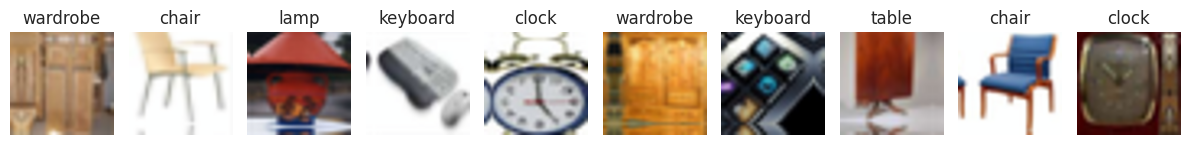


Information on test set
Statistics for test
 Size: 1000
 Samples per class:
  clock: 100
  keyboard: 100
  lamp: 100
  telephone: 100
  television: 100
  bed: 100
  chair: 100
  couch: 100
  table: 100
  wardrobe: 100
Examples of images from the test set


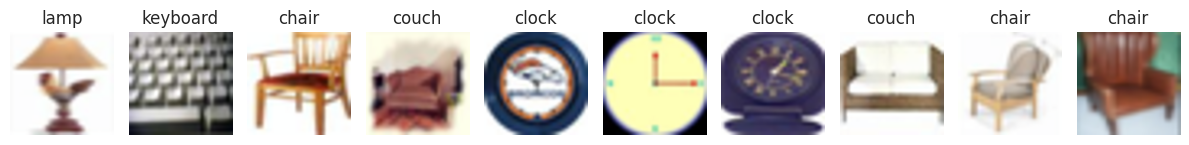

In [9]:
# Target input resolution for the model.
# The resize now lives in preprocessing (not inside the model), so input
# resolution is an explicit latency lever. 224 reproduces the original
# MobileNetV3 contract used to train the baseline.
BASELINE_RESIZE = 224

# Load household objects dataset
train_loader, test_loader = get_household_loaders(
    image_size="CIFAR", batch_size=128, num_workers=2, resize=BASELINE_RESIZE,
)

# Benchmark at the true model input resolution (resize now happens in
# preprocessing, so the model sees BASELINE_RESIZE x BASELINE_RESIZE inputs).
input_size = (1, 3, BASELINE_RESIZE, BASELINE_RESIZE)
print(f"Input has size: {input_size}")

# Get class names
class_names = train_loader.dataset.classes
print(f"Datasets have these classes: ")
for i in range(len(class_names)):
    print(f"  {i}: {class_names[i]}")

# Visualize some examples
for dataset_type, data_loader in [('train', train_loader), ('test', test_loader)]:
    print(f"\nInformation on {dataset_type} set")
    print_dataloader_stats(data_loader, dataset_type)
    print(f"Examples of images from the {dataset_type} set")
    visualize_batch(data_loader, num_images=10)


### Step 3: Load the baseline model and metrics

In [10]:
# Load the baseline model
baseline_model = MobileNetV3_Household()
baseline_model_name = "baseline_mobilenet"
baseline_model.load_state_dict(torch.load(f"../models/{baseline_model_name}/checkpoints/model.pth"))
print_model_summary(baseline_model)

# Load baseline metrics
with open(f"../results/{baseline_model_name}/metrics.json", "r") as f:
    baseline_metrics = json.load(f)

print("\nBaseline Model Metrics:")
pprint.pp(baseline_metrics)

# Calculate target metrics based on CTO requirements
target_model_size = baseline_metrics['size']['model_size_mb'] * (1 - TARGET_MODEL_COMPRESSION)
target_inference_time_cpu = baseline_metrics['timing']['cpu']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
if torch.cuda.is_available():
    target_inference_time_gpu = baseline_metrics['timing']['cuda']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
min_acceptable_accuracy = baseline_metrics['accuracy']['top1_acc'] * (1 - MAX_ALLOWED_ACCURACY_DROP) 

print("Optimization Targets:")
print(f"Target Model Size: {baseline_metrics['size']['model_size_mb']:.2f} --> {target_model_size:.2f} MB ({TARGET_MODEL_COMPRESSION*100}% reduction)")
print(f"Target Inference Time (CPU): {baseline_metrics['timing']['cpu']['avg_time_ms']:.2f} --> {target_inference_time_cpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
if torch.cuda.is_available():
    print(f"Target Inference Time (GPU): {baseline_metrics['timing']['cuda']['avg_time_ms']:.2f} --> {target_inference_time_gpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
print(f"Minimum Acceptable Accuracy: {baseline_metrics['accuracy']['top1_acc']:.2f} --> {min_acceptable_accuracy:.2f} (within {MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /home/student/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth
100.0%
/tmp/ipykernel_116/3650396802.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please op

Model Architecture:
MobileNetV3_Household(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
   

### Step 4: Implement and evaluate compression techniques

Now you'll implement and evaluate different compression techniques. For each technique that you choose, you'll:
1. Implement the technique
2. Evaluate its impact on model size, inference time, and accuracy
3. Analyze the trade-offs

To choose a technique, simply uncomment the apply_{TECHNIQUE_NAME}_technique() function call in the corresponding technique cell block.

#### 4.1 Post-Training - Quantization

Quantization reduces the precision of weights and activations, converting floating-point values to integers.


> **⚠️ Backend note (see Notebook 03, Step 4.0 — "Diagnose the int8 backend anomaly").**
> The results below originally showed static PTQ collapsing to ~12–14% accuracy **and** running
> ~36× *slower* than fp32. Notebook 03 isolated **two independent causes**:
> 1. **Latency (fixable):** the old `qnnpack`-if-supported heuristic picked slow *reference* kernels
>    on x86. This cell now selects **`fbgemm` on x86 / `qnnpack` on ARM**, which removes the slowdown.
> 2. **Accuracy (not fixable by backend):** MobileNetV3's **hard-swish / SE blocks** are mis-quantized
>    by the default qconfig, so int8 accuracy still collapses regardless of backend — it needs a custom
>    qconfig or QAT. This is why the downstream pipelines in Notebook 03 stay **quantization-free**.

Using quantization backend: fbgemm (x86 CPU detected)
Applying static quantization with fbgemm backend


/workspace/code/project/starter-kit/utils/model.py:104: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(path, map_location=device)


Applying static quantization...
Calibrating on 10 batch(es)...


Calibration: 100%|██████████| 10/10 [01:09<00:00,  6.98s/it]


Model saved to ../models/post_training/quantization/static/model.pth
✅ Model is quantized

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:13<00:00,  1.75s/it]


INFO: Detected quantized CPU-only model. Skipping CUDA latency evaluation.
Baseline metrics saved at ../results/post_training/quantization/static/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:12<00:00,  1.62s/it]


Confusion matrix saved to ../results/post_training/quantization/static/confusion_matrix.png


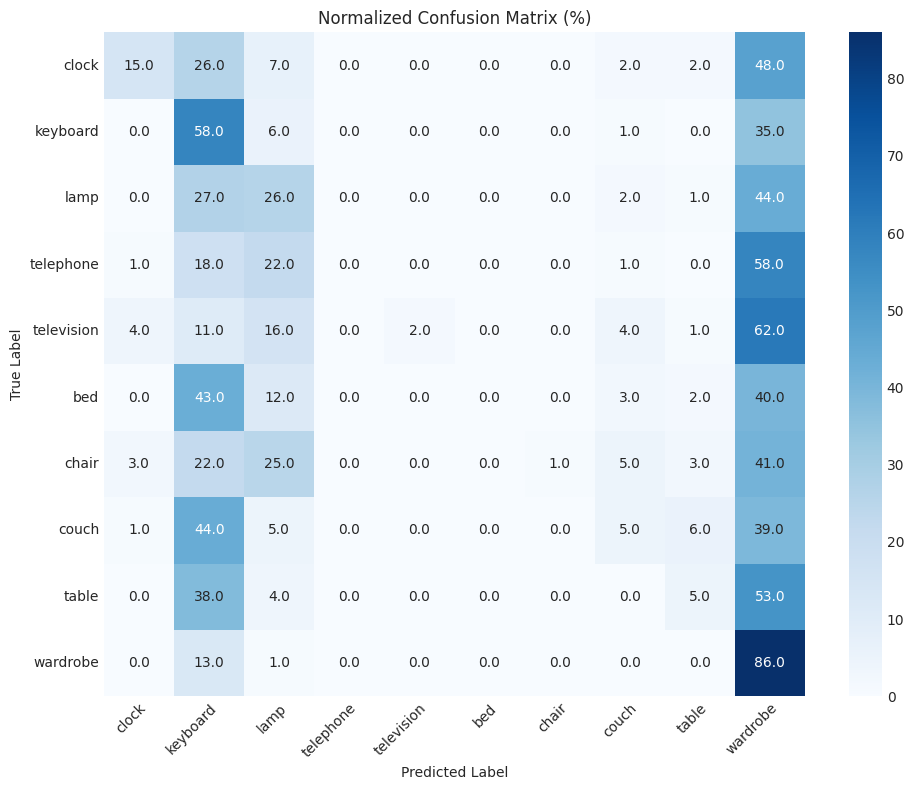


Optimized Model Metrics (post_training/quantization/static):
Accuracy: 19.50%
Model Size: 1.75 MB
CPU Inference Time: 9.63 ms (103.88 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:32<00:00,  4.04s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:14<00:00,  1.76s/it]


INFO: Detected quantized CPU-only model. Skipping CUDA latency evaluation.
Model comparison plot saved to ../results/post_training/quantization/static/comparison.png


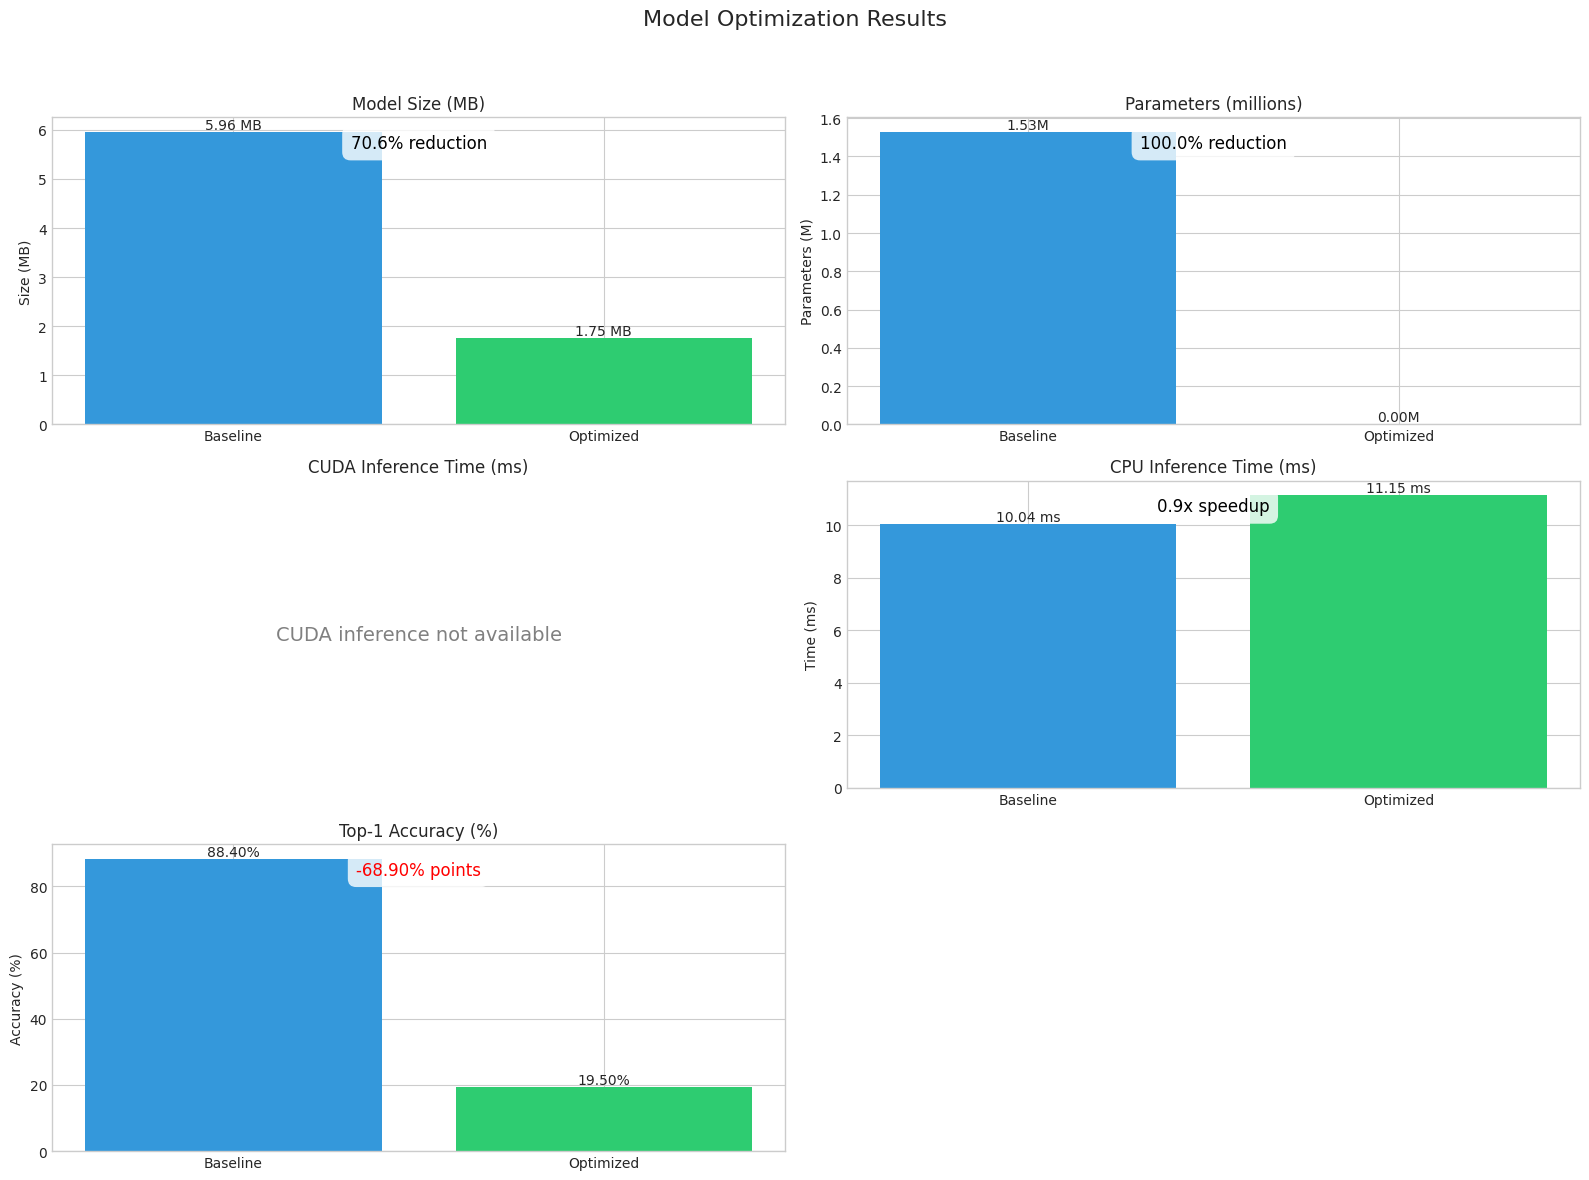


post_training/quantization/static Results:
Model Size: 1.75 MB (70.6% reduction)
Parameters: 0 (100.0% reduction)
CPU Inference Time: 11.15 ms (0.9x speedup)
Accuracy: 19.50% (-68.90% change)
Requirements met: False


In [11]:
# Define a function to apply quantization and evaluate results
def apply_post_training_quantization(quantization_type, backend, device):
    """
    Apply quantization to a model with given method and backend.
    
    Args:
        quantization_type: Quantization method ("static" or "dynamic")
        backend: Backend for quantization ("fbgemm" for x86 or "qnnpack" for ARM)
        device: Which device to use for model loading, training, and evaluation
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Define unique experiment name given main parameters
    experiment_name = f"post_training/quantization/{quantization_type}"
    
    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying {quantization_type} quantization with {backend} backend")
    
    # Make a copy of the baseline model and move to specified device
    orig_model = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth").to(device)
    orig_model.eval()
    
    # Apply post-training quantization
    quantized_model = quantize_model(
        orig_model,
        quantization_type=quantization_type,
        calibration_data_loader=train_loader if quantization_type == "static" else None,
        calibration_num_batches=10 if quantization_type == "static" else None,  # ~10 batches is enough to estimate activation ranges
        backend=backend,
    )
    
    # Save the quantized model
    save_model(quantized_model, f"../models/{experiment_name}/model.pth")
    
    # Check that model is indeed quantized
    is_quantized(quantized_model)
    
    # Evaluate quantized model
    evaluate_optimized_model(
        quantized_model, test_loader, experiment_name, class_names, input_size, device=torch.device('cpu')
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        quantized_model,
        experiment_name,
        test_loader,
        class_names,
        device=torch.device('cpu'),
    )
    
    return quantized_model, comparison_results, experiment_name

#### Apply post-training quantization
## Find info at https://pytorch.org/docs/stable/quantization.html

## Parameter selection & justification:
## - "static" quantization pre-quantizes BOTH weights and activations to int8
##   using a short calibration pass. This delivers the largest size reduction
##   (~4x on quantized layers) and the best CPU latency, at a small accuracy
##   cost that calibration keeps in check. (Dynamic quantizes only Linear/RNN
##   weights, so it helps less on this conv-dominated MobileNet.)
## - The backend must match the target CPU ISA: qnnpack (ARM/mobile, the
##   UdaciSense deployment target) or fbgemm (x86 servers/dev machines).
## - Quantized kernels execute on CPU, so calibration/conversion use CPU.
quantization_type = "static"  # One of "dynamic" or "static"
# Pick the backend that matches THIS CPU's ISA. qnnpack is *listed* on x86 too,
# but there it runs slow reference kernels; it is only the right choice on ARM/
# mobile. On x86, fbgemm is the correct (fast) backend. Using the old
# "prefer qnnpack if supported" heuristic is what made static PTQ/QAT run ~36x
# slower than fp32 here (see Notebook 03, Step 4.0). NOTE: this fixes LATENCY only
# -- the accuracy collapse is MobileNetV3's hard-swish/SE blocks being mis-quantized
# by the default qconfig, which the backend choice does not address.
import platform
_is_arm = any(k in platform.machine().lower() for k in ("arm", "aarch"))
backend = "qnnpack" if _is_arm else "fbgemm"
print(f"Using quantization backend: {backend} ({'ARM' if _is_arm else 'x86'} CPU detected)")
device = torch.device("cpu")  # PTQ calibration and int8 inference run on CPU

# Optimize and evaluate model
quantized_model_static, quantized_comparison_results, experiment_name = apply_post_training_quantization(quantization_type, backend=backend, device=device)

#### 4.2 In-training - Quantization

Quantization-aware training simulates quantization during training, allowing the model to adapt to the reduced precision.

> **⚠️ Backend note (see Notebook 03, Step 4.0).** The same `fbgemm`(x86)/`qnnpack`(ARM) fix is applied
> here so QAT latency is measured correctly. As with static PTQ, the backend choice fixes **speed only** —
> the residual accuracy loss comes from the default qconfig mis-quantizing MobileNetV3's hard-swish / SE
> blocks, not from the backend.

Using quantization backend: fbgemm (x86 CPU detected)
Applying quantization-aware training with QAT starting at epoch 1 / ending at 8
Training with quantization-aware training for 8 epochs
QAT start epoch: 1, Finetune BN stats epochs: 4
QAT will be activated after epoch 1


Epoch 1/8 [Test]: 100%|██████████| 8/8 [00:01<00:00,  4.49it/s, loss=1.56, acc=56.7]


Epoch 1/8 - Train Loss: 1.9726, Train Acc: 43.58%, Test Loss: 1.5596, Test Acc: 56.70%, LR: 0.000096, Time: 12.01s
Preparing model for quantization-aware training...


Epoch 2/8 [Test]: 100%|██████████| 8/8 [00:16<00:00,  2.04s/it, loss=2.4, acc=12.1] 


Epoch 2/8 - Train Loss: 2.1352, Train Acc: 23.76%, Test Loss: 2.4026, Test Acc: 12.10%, LR: 0.000089, Time: 32.33s
New best quantized model! Saving... (12.10%)
Model saved to /workspace/code/project/starter-kit/notebooks/../models/in_training/quantization/epochs8_start1/checkpoints


...

Epoch 8/8 - Train Loss: 1.7202, Train Acc: 40.20%, Test Loss: 1.6577, Test Acc: 43.70%, LR: 0.000000, Time: 29.00s
New best quantized model! Saving... (43.70%)
Model saved to /workspace/code/project/starter-kit/notebooks/../models/in_training/quantization/epochs8_start1/checkpoints
Training completed. Best accuracy: 43.70%
Best QAT model saved as '/workspace/code/project/starter-kit/notebooks/../models/in_training/quantization/epochs8_start1/checkpoints' at epoch 8
Converting best QAT model to fully quantized model...
Model saved to ../models/in_training/quantization/epochs8_start1/model.pth
✅ Model is quantized

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:13<00:00,  1.72s/it]


INFO: Detected quantized CPU-only model. Skipping CUDA latency evaluation.
Baseline metrics saved at ../results/in_training/quantization/epochs8_start1/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:15<00:00,  1.93s/it]


Confusion matrix saved to ../results/in_training/quantization/epochs8_start1/confusion_matrix.png


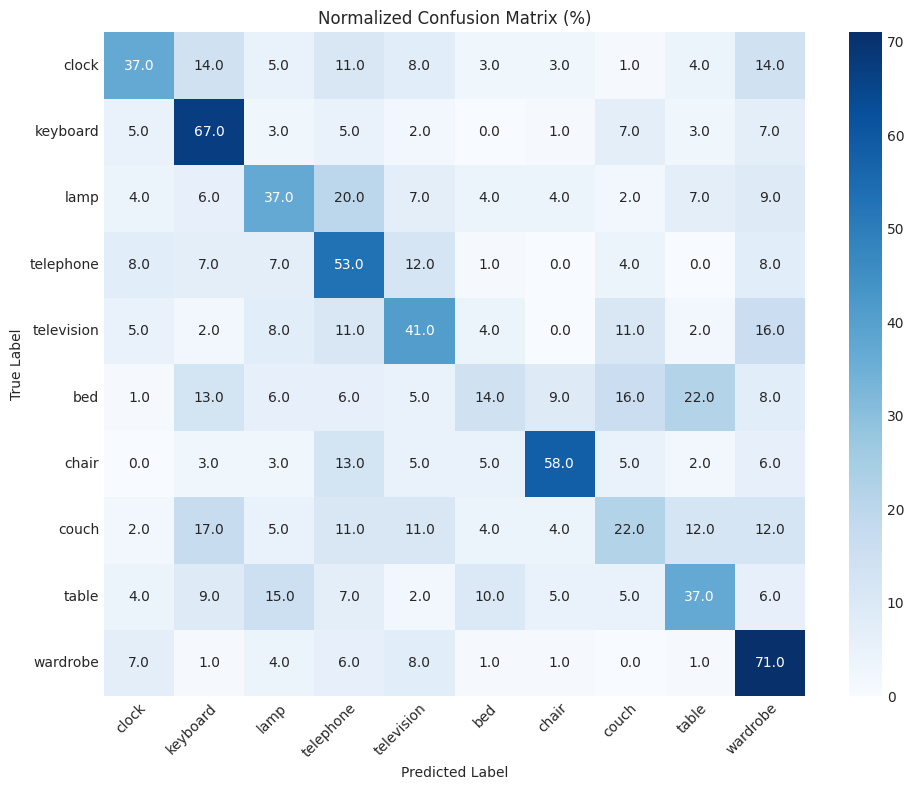

No suitable layers found for weight distribution visualization.
Training history plot saved to ../results/in_training/quantization/epochs8_start1/training_history.png


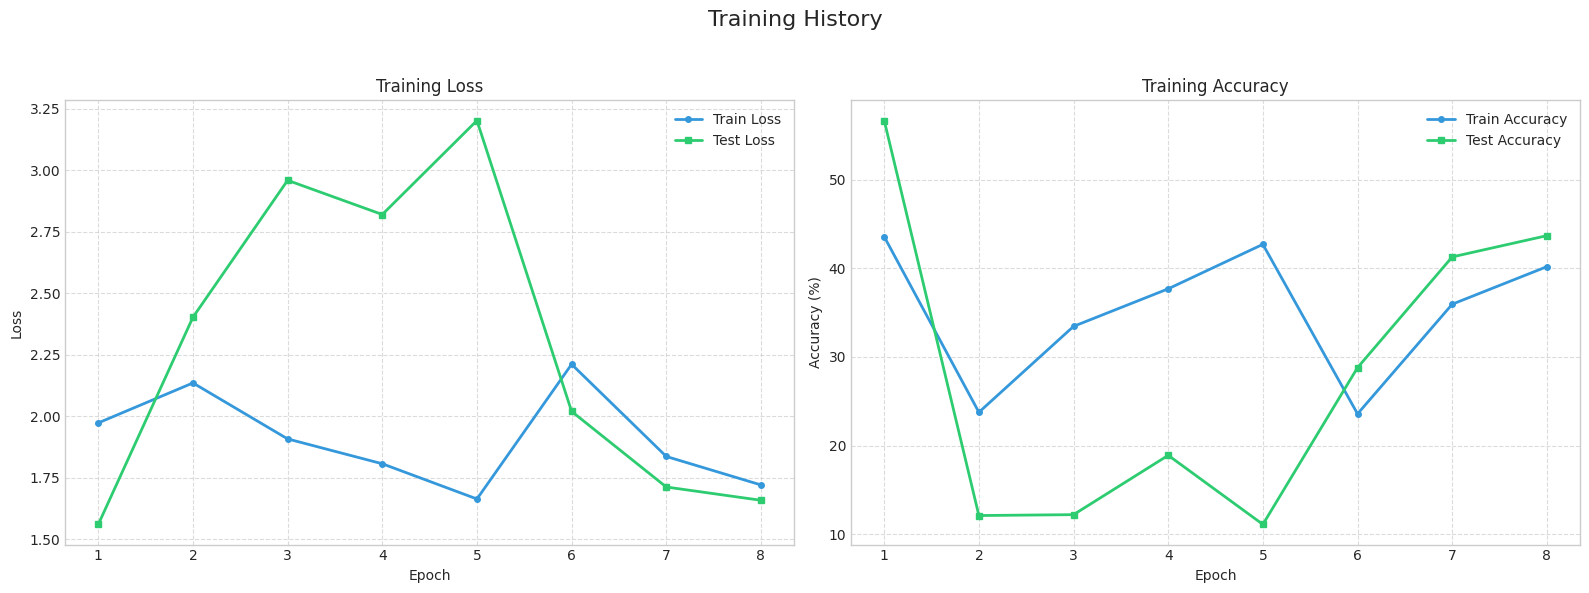


Optimized Model Metrics (in_training/quantization/epochs8_start1):
Accuracy: 43.30%
Model Size: 1.76 MB
CPU Inference Time: 11.08 ms (90.25 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:22<00:00,  2.79s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:15<00:00,  1.91s/it]


INFO: Detected quantized CPU-only model. Skipping CUDA latency evaluation.
Model comparison plot saved to ../results/in_training/quantization/epochs8_start1/comparison.png


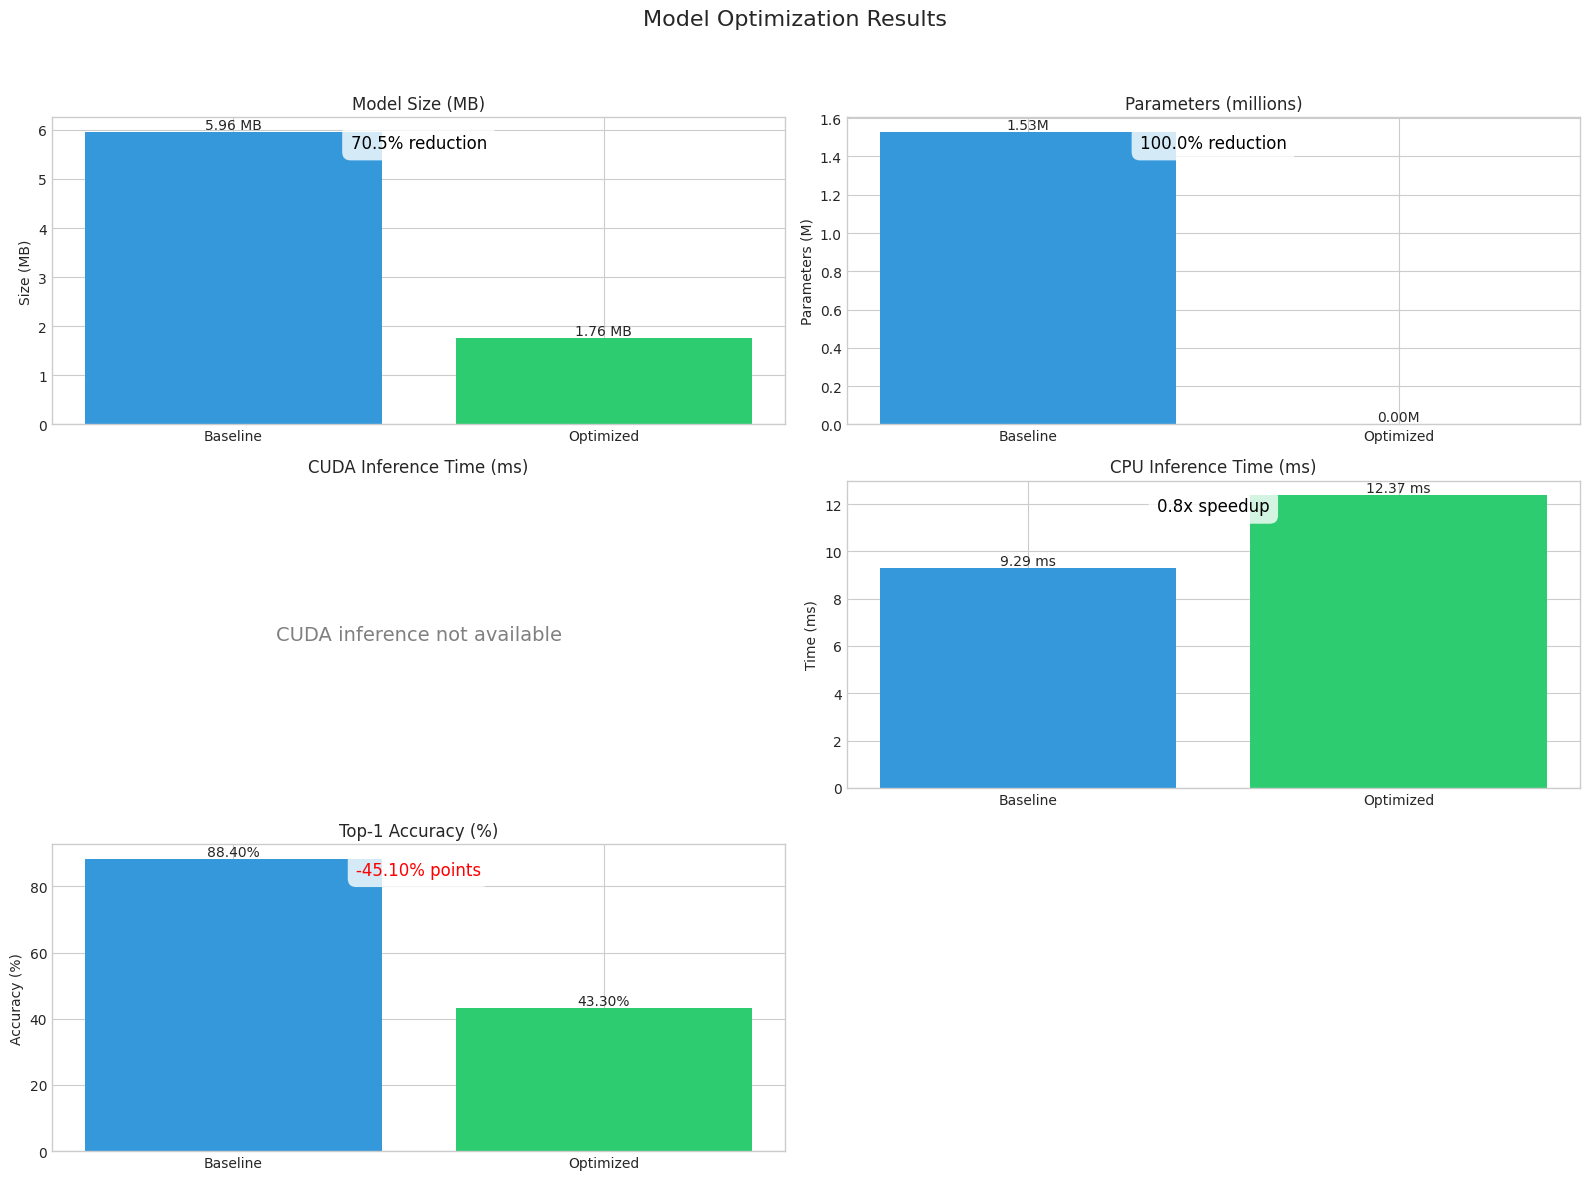


in_training/quantization/epochs8_start1 Results:
Model Size: 1.76 MB (70.5% reduction)
Parameters: 0 (100.0% reduction)
CPU Inference Time: 12.37 ms (0.8x speedup)
Accuracy: 43.30% (-45.10% change)
Requirements met: False


In [12]:
# Define a function to apply quantization-aware training and evaluate results
def apply_quantization_aware_training(model, config, backend):
    """
    Apply quantization-aware training to a model.
    
    Args:
        model: The model architecture to quantize
        config: Dictionary containing the training configuration for the experiment
        backend: Backend for quantization ("fbgemm" for x86 or "qnnpack" for ARM)
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Extract relevant training parameters for logging
    qat_start_epoch, num_epochs = config['qat_start_epoch'], config['num_epochs']
    
    # Define unique experiment name given main parameters
    experiment_name = f"in_training/quantization/epochs{num_epochs}_start{qat_start_epoch}"
    experiment_name = experiment_name.replace('.', '-')
    
    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying quantization-aware training with QAT starting at epoch {qat_start_epoch} / ending at {num_epochs}")
        
    # Move model to specified device
    model = model.to(config['device'])
    
    # Train with QAT
    quantized_model, qat_stats, qat_best_accuracy, qat_best_epoch = train_model_qat(
        model,
        train_loader,
        test_loader,
        config,
        checkpoint_path=f"{os.getcwd()}/../models/{experiment_name}/checkpoints",  # Providing full path to manage different sub-directory depths in utility scripts
        backend=backend,
    )
    
    # Save training statistics
    with open(f"../results/{experiment_name}/training_stats.json", 'w') as f:
        json.dump(qat_stats, f, indent=4)
    
    # Save the quantized model
    save_model(quantized_model, f"../models/{experiment_name}/model.pth")
    
    # Check that model is indeed quantized
    is_quantized(quantized_model)
    
    # Evaluate quantized model
    metrics, confusion_matrix = evaluate_optimized_model(
        quantized_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        is_in_training_technique=True,
        training_stats=qat_stats,
        device=config["device_for_inference"],
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        quantized_model,
        experiment_name,
        test_loader,
        class_names,
        device=config["device_for_inference"],
    )
    
    return quantized_model, comparison_results, experiment_name

#### Apply quantization-aware training
## Find info at https://pytorch.org/docs/stable/quantization.html

## Create quantizable model version
model = QuantizableMobileNetV3_Household(quantize=False)

## Parameter selection & justification:
## - qat_start_epoch=1: train 1 warm-up epoch in fp32 so weights settle before
##   inserting fake-quant observers; starting QAT too early destabilizes training.
## - freeze_bn_epochs=4 and disable_observer_epoch=5: late in training we freeze
##   BatchNorm running stats and stop updating activation quant ranges so the
##   int8 scales/zero-points match what inference will actually use -> higher
##   post-conversion accuracy.
## - AdamW at a LOW lr (1e-4): QAT is a fine-tuning stage; large steps would fight
##   the fake-quant noise. Cosine schedule anneals it smoothly.
## - grad_clip_norm=1.0 keeps the extra gradient noise from fake-quant bounded.
## - Train on GPU when available, but CONVERT + measure latency on CPU, because
##   int8 kernels only run on CPU (the mobile target).
qat_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
qat_num_epochs = 8
qat_criterion = nn.CrossEntropyLoss()
qat_optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
qat_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(qat_optimizer, T_max=qat_num_epochs)
config = {
    'qat_start_epoch': 1,  # Integer
    'freeze_bn_epochs': 4,  # Integer
    'disable_observer_epoch': 5,  # Integer: stop updating quant ranges near the end
    'num_epochs': qat_num_epochs,  # Integer
    'criterion': qat_criterion,  # A PyTorch loss
    'optimizer': qat_optimizer,  # A PyTorch optimizer
    'scheduler': qat_scheduler,  # A PyTorch scheduler
    'patience': 5,  # Integer
    'device': qat_device,  # Define with torch.device()
    'device_for_inference': torch.device('cpu'),  # Define with torch.device()
    'grad_clip_norm': 1.0,  # Float
}
# Pick the backend that matches THIS CPU's ISA. qnnpack is *listed* on x86 too,
# but there it runs slow reference kernels; it is only the right choice on ARM/
# mobile. On x86, fbgemm is the correct (fast) backend. Using the old
# "prefer qnnpack if supported" heuristic is what made static PTQ/QAT run ~36x
# slower than fp32 here (see Notebook 03, Step 4.0). NOTE: this fixes LATENCY only
# -- the accuracy collapse is MobileNetV3's hard-swish/SE blocks being mis-quantized
# by the default qconfig, which the backend choice does not address.
import platform
_is_arm = any(k in platform.machine().lower() for k in ("arm", "aarch"))
backend = "qnnpack" if _is_arm else "fbgemm"
print(f"Using quantization backend: {backend} ({'ARM' if _is_arm else 'x86'} CPU detected)")

# Optimize and evaluate model
qat_model, qat_comparison_results, experiment_name = apply_quantization_aware_training(model, config, backend)

#### 4.3 Post-training - Pruning

Pruning reduces model size by removing weights with small magnitudes that contribute less to the output.

Applying post-training pruning with method global_unstructured and amount 0.50
Pruning 54 modules with method: global_unstructured, amount: 0.5
Initial model sparsity: 0.00%


/workspace/code/project/starter-kit/utils/model.py:104: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(path, map_location=device)


✅ Model is pruned
Final model sparsity: 49.87%
Model saved to ../models/post_training/pruning/global_unstructured_0-5_cpu/model.pth

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:30<00:00,  3.85s/it]


Baseline metrics saved at ../results/post_training/pruning/global_unstructured_0-5_cpu/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:28<00:00,  3.51s/it]


Confusion matrix saved to ../results/post_training/pruning/global_unstructured_0-5_cpu/confusion_matrix.png


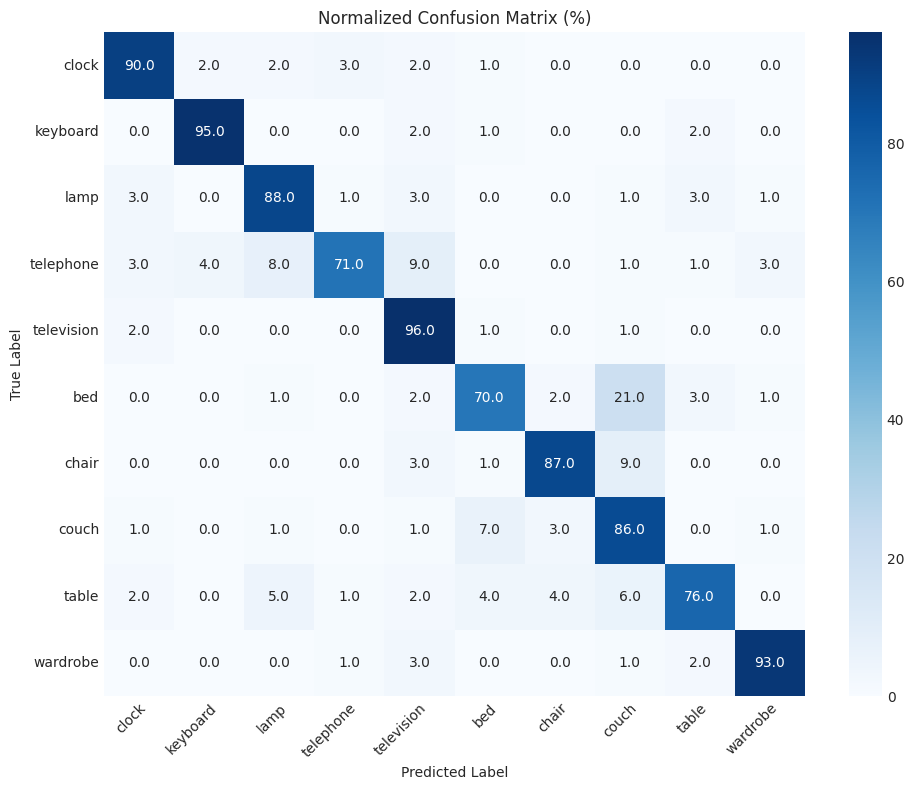


Optimized Model Metrics (post_training/pruning/global_unstructured_0-5_cpu):
Accuracy: 85.20%
Model Size: 5.96 MB
CPU Inference Time: 9.99 ms (100.07 FPS)
CUDA Inference Time: 5.54 ms (180.59 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:29<00:00,  3.64s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:28<00:00,  3.61s/it]


Model comparison plot saved to ../results/post_training/pruning/global_unstructured_0-5_cpu/comparison.png


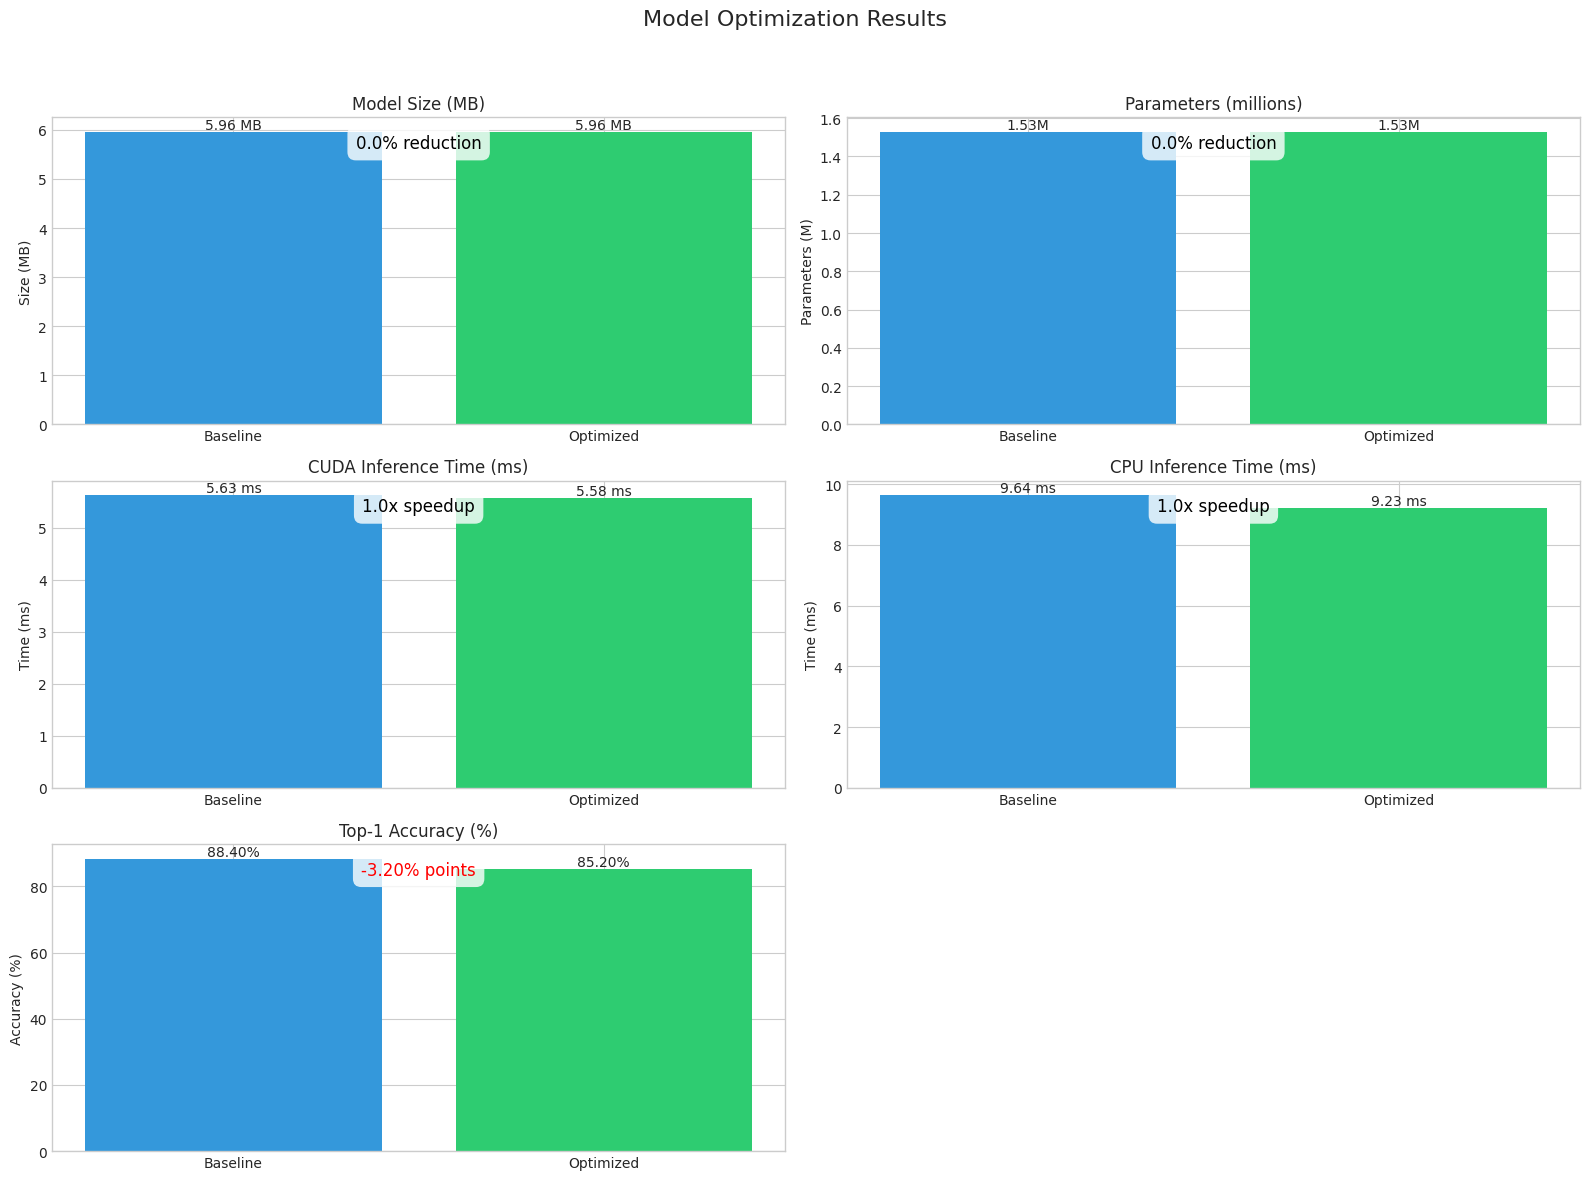


post_training/pruning/global_unstructured_0-5_cpu Results:
Model Size: 5.96 MB (0.0% reduction)
Parameters: 1,528,106 (0.0% reduction)
CPU Inference Time: 9.23 ms (1.0x speedup)
CUDA Inference Time: 5.58 ms (1.0x speedup)
Accuracy: 85.20% (-3.20% change)
Requirements met: False


In [13]:
# Define a function to apply pruning and evaluate results
def apply_post_training_pruning(config):
    """
    Apply post-training pruning to a model with given pruning method and amount
    
    Args:
        config: Dictionary containing the configuration for the experiment
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Extract relevant training parameters for logging
    amount, pruning_method, device = config['amount'], config['pruning_method'], config['device']
    
    # Define unique experiment name given main parameters
    experiment_name = f"post_training/pruning/{pruning_method}_{amount}_{device}"
    experiment_name = experiment_name.replace('.', '-')
    
    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying post-training pruning with method {pruning_method} and amount {amount:.2f}")
    
    # Make a copy of the baseline model and move to specified device
    orig_model = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth").to(device)
    orig_model.eval()
    
    # Apply post-training pruning
    pruned_model = prune_model(orig_model, pruning_method, amount, config["modules_to_prune"], config["custom_pruning_fn"])
    
    # Save the pruned model
    save_model(pruned_model, f"../models/{experiment_name}/model.pth")
    
    # Evaluate pruned model
    metrics, confusion_matrix = evaluate_optimized_model(
        pruned_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        device=device,
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        pruned_model,
        experiment_name,
        test_loader,
        class_names,
        device=device,
    )
    
    return pruned_model, comparison_results, experiment_name


# Apply post-training pruning    
## Find info at https://pytorch.org/tutorials/intermediate/pruning_tutorial.html

## Parameter selection & justification:
## - "global_unstructured" ranks weights by magnitude ACROSS all layers and drops
##   the globally smallest ones. This respects each layer's sensitivity better than
##   a fixed per-layer ratio, so accuracy holds up at higher sparsity.
## - amount=0.5 comes from the hyperparameter search in the next cell (best trade
##   -off of size reduction vs. accuracy on this model). Unstructured pruning zeros
##   weights but keeps dense tensors, so on-disk size only shrinks after export /
##   sparse encoding; its main win here is enabling further pipeline compression.
## - modules_to_prune=None -> default to all Conv2d + Linear layers.
## - Pruning is a pure tensor op, so CPU is fine and deterministic.
config = {
    'pruning_method': "global_unstructured",  # String
    'amount': 0.5,  # Float
    'modules_to_prune': None,  # (Optional) List -> None means all Conv2d + Linear
    'n': None,  # (Optional: Used for ln_structured pruning) Int
    'dim': None,  # Optional: Used for ln_structured pruning) Int
    'custom_pruning_fn': None,  # (Optional) Fn
    'device': torch.device("cpu"),  # Define with torch.device()
}

# Optimize and evaluate model
pruned_model, pruned_results, experiment_name = apply_post_training_pruning(config)

In [14]:
# ── Hyperparameter search: post-training pruning amount ──────────────────────
# Post-training pruning has essentially ONE dominant knob: how much to prune.
# We search it efficiently with Optuna (falling back to a grid scan if Optuna
# isn't installed). No retraining is needed, so each trial just prunes a fresh
# copy of the baseline and scores the size/accuracy trade-off on a small
# validation subset -> the whole search runs in seconds-to-minutes on CPU.
import copy as _copy
from itertools import islice

_hp_device = torch.device("cpu")


def _quick_accuracy(model, loader, device, max_batches=8):
    """Fast top-1 estimate over a few batches (no full-set eval needed)."""
    model.eval()
    correct, total = 0, 0
    with torch.inference_mode():
        for inputs, targets in islice(loader, max_batches):
            inputs, targets = inputs.to(device), targets.to(device)
            preds = model(inputs).argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)
    return 100.0 * correct / max(total, 1)


# Reference accuracy on the same subset, measured once.
_ref_model = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth").to(_hp_device)
_baseline_acc_subset = _quick_accuracy(_ref_model, test_loader, _hp_device)
del _ref_model


def _score_pruning_amount(amount):
    """Reward size reduction (amount) while penalizing accuracy drop past budget."""
    m = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth").to(_hp_device)
    m.eval()
    m = prune_model(m, "global_unstructured", amount, None, None)
    acc = _quick_accuracy(m, test_loader, _hp_device)
    del m
    acc_drop = max(0.0, _baseline_acc_subset - acc)
    return amount * 100.0 - 4.0 * acc_drop  # penalty weight balances size vs accuracy


try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def _objective(trial):
        amount = trial.suggest_float("amount", 0.2, 0.8)
        return _score_pruning_amount(amount)

    study = optuna.create_study(direction="maximize")
    study.optimize(_objective, n_trials=15, show_progress_bar=False)
    best_amount = study.best_params["amount"]
    print(f"[Optuna] Best pruning amount: {best_amount:.3f} (score={study.best_value:.2f})")
except ImportError:
    grid = [round(a, 2) for a in np.linspace(0.2, 0.8, 13)]
    scored = [(a, _score_pruning_amount(a)) for a in grid]
    best_amount, best_score = max(scored, key=lambda x: x[1])
    print(f"[Grid] Best pruning amount: {best_amount:.3f} (score={best_score:.2f})")

print(f"Baseline subset accuracy: {_baseline_acc_subset:.2f}%")
print(f"Recommended pruning amount (round to use in the config above): {best_amount:.2f}")

/workspace/code/project/starter-kit/utils/model.py:104: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(path, map_location=device)


Pruning 54 modules with method: global_unstructured, amount: 0.2
Initial model sparsity: 0.00%
✅ Model is pruned
Final model sparsity: 19.95%
Pruning 54 modules with method: global_unstructured, amount: 0.25
Initial model sparsity: 0.00%
✅ Model is pruned
Final model sparsity: 24.94%
Pruning 54 modules with method: global_unstructured, amount: 0.3
Initial model sparsity: 0.00%
✅ Model is pruned
Final model sparsity: 29.92%
Pruning 54 modules with method: global_unstructured, amount: 0.35
Initial model sparsity: 0.00%
✅ Model is pruned
Final model sparsity: 34.91%
Pruning 54 modules with method: global_unstructured, amount: 0.4
Initial model sparsity: 0.00%
✅ Model is pruned
Final model sparsity: 39.90%
Pruning 54 modules with method: global_unstructured, amount: 0.45
Initial model sparsity: 0.00%
✅ Model is pruned
Final model sparsity: 44.88%
Pruning 54 modules with method: global_unstructured, amount: 0.5
Initial model sparsity: 0.00%
✅ Model is pruned
Final model sparsity: 49.87%
Pru

#### 4.4 In-training - Pruning

Gradual pruning progressively prunes weights during training, allowing the model to adapt to increasing sparsity.

Applying gradual pruning from 0.0% to 60.0% sparsity
Total parameters: 1,528,106
Training with gradual pruning for 15 epochs
Pruning schedule: 0.00% → 60.00% sparsity from epoch 2 to 12


Epoch 1/15 [Test]: 100%|██████████| 8/8 [00:01<00:00,  4.54it/s, loss=1.35, acc=64]  


Epoch 1/15 - Train Loss: 1.0046, Train Acc: 66.50%, Test Loss: 1.3543, Test Acc: 64.00%, Sparsity: 0.00%, LR: 0.000989, Time: 12.62s


Epoch 2/15 [Test]: 100%|██████████| 8/8 [00:01<00:00,  4.50it/s, loss=1.09, acc=71.7] 


Epoch 2/15 - Train Loss: 0.4079, Train Acc: 86.02%, Test Loss: 1.0911, Test Acc: 71.70%, Sparsity: 0.00%, LR: 0.000957, Time: 13.08s


...

Epoch 15/15 - Train Loss: 0.0152, Train Acc: 99.74%, Test Loss: 0.3892, Test Acc: 89.80%, Sparsity: 59.84%, LR: 0.000000, Time: 10.44s
New best pruned model! Saving... (89.80%)
Model saved to ../models/in_training/pruning/global_unstructured_sparsity0-0-0-6_epochs2-12/model.pth
Making pruning permanent on best model...
✅ Model is pruned
Model saved to ../models/in_training/pruning/global_unstructured_sparsity0-0-0-6_epochs2-12/model.pth
Training completed. Best accuracy: 89.80%
Best model saved as '../models/in_training/pruning/global_unstructured_sparsity0-0-0-6_epochs2-12/model.pth' at epoch 15
Final model sparsity: 59.84%
Model saved to ../models/in_training/pruning/global_unstructured_sparsity0-0-0-6_epochs2-12/model.pth

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:01<00:00,  4.62it/s]


Baseline metrics saved at ../results/in_training/pruning/global_unstructured_sparsity0-0-0-6_epochs2-12/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:01<00:00,  4.73it/s]


Confusion matrix saved to ../results/in_training/pruning/global_unstructured_sparsity0-0-0-6_epochs2-12/confusion_matrix.png


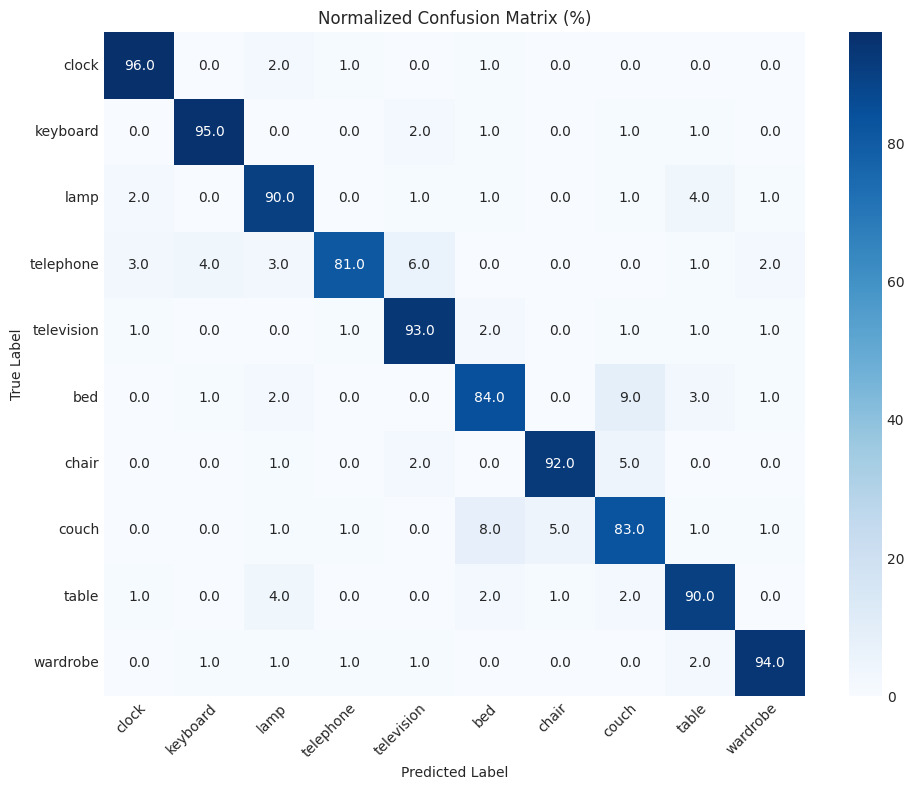

Weight distribution plot saved to ../results/in_training/pruning/global_unstructured_sparsity0-0-0-6_epochs2-12/weight_distribution.png


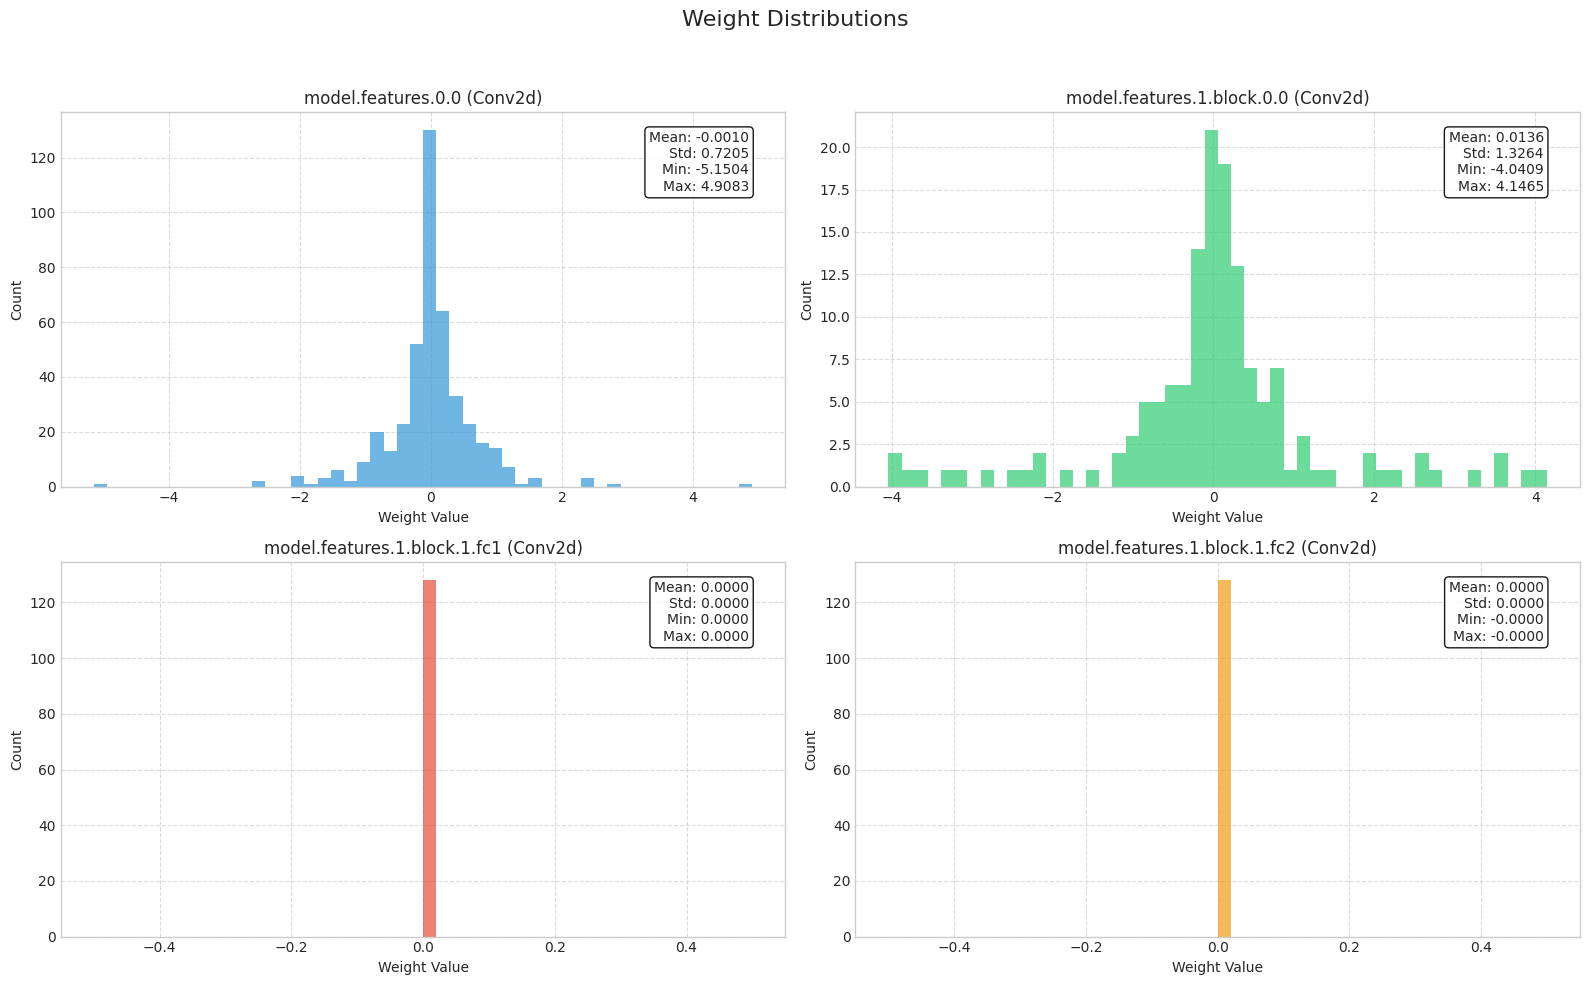

Training history plot saved to ../results/in_training/pruning/global_unstructured_sparsity0-0-0-6_epochs2-12/training_history.png


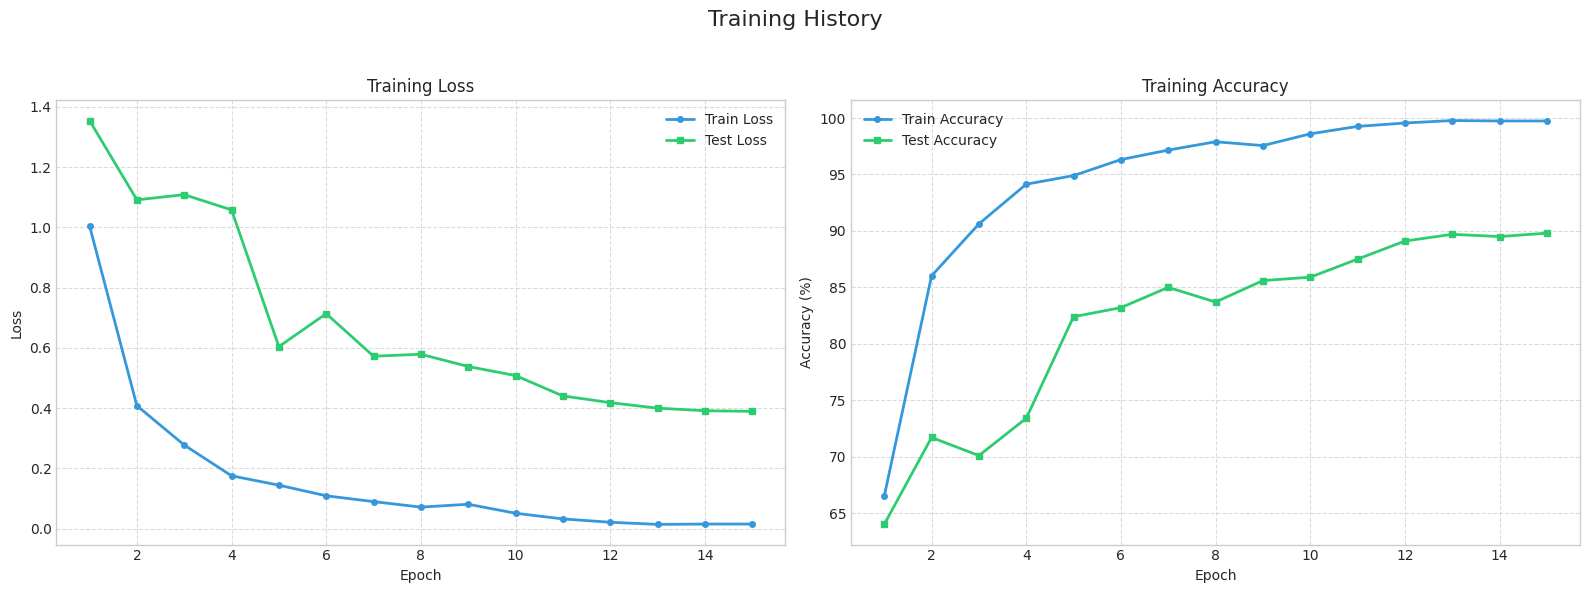


Optimized Model Metrics (in_training/pruning/global_unstructured_sparsity0-0-0-6_epochs2-12):
Accuracy: 89.80%
Model Size: 5.96 MB
CPU Inference Time: 9.07 ms (110.26 FPS)
CUDA Inference Time: 5.95 ms (167.96 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:01<00:00,  5.05it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:01<00:00,  4.93it/s]


Model comparison plot saved to ../results/in_training/pruning/global_unstructured_sparsity0-0-0-6_epochs2-12/comparison.png


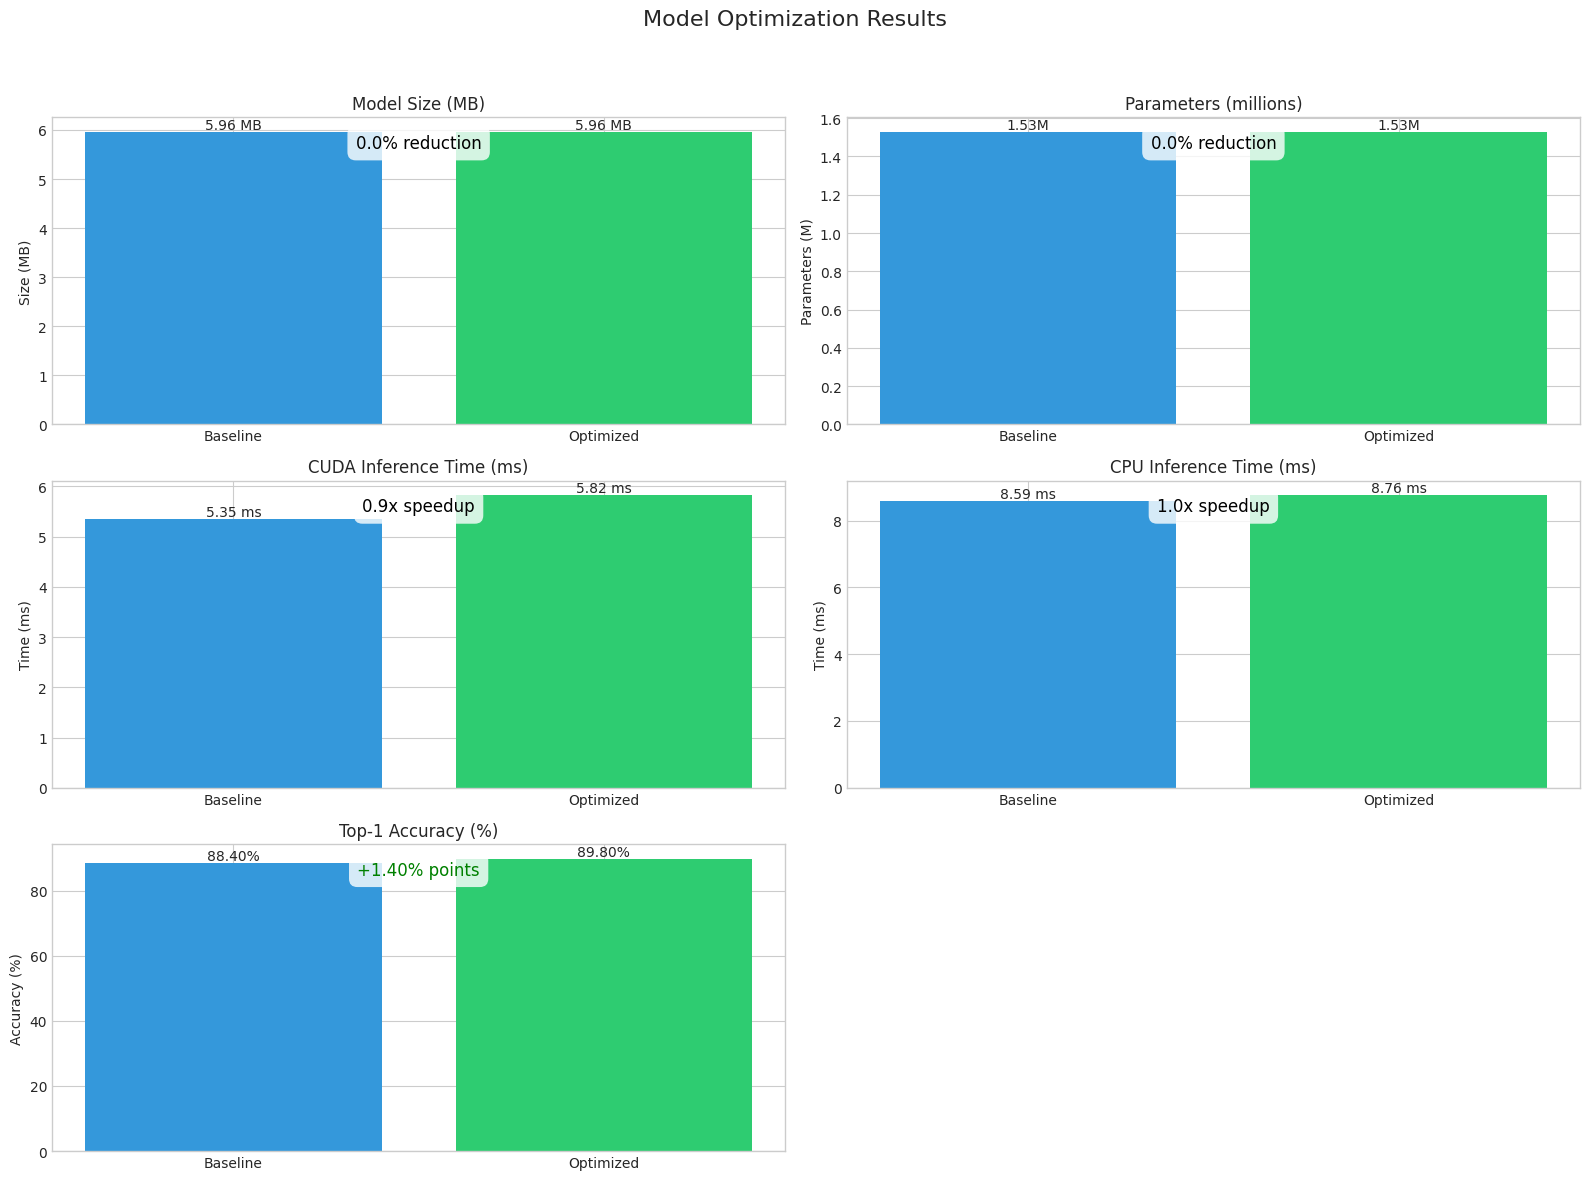


in_training/pruning/global_unstructured_sparsity0-0-0-6_epochs2-12 Results:
Model Size: 5.96 MB (0.0% reduction)
Parameters: 1,528,106 (0.0% reduction)
CPU Inference Time: 8.76 ms (1.0x speedup)
CUDA Inference Time: 5.82 ms (0.9x speedup)
Accuracy: 89.80% (+1.40% change)
Requirements met: False


In [15]:
# Define a function to apply pruning during training and evaluate results
def apply_in_training_pruning(model, config):
    """
    Apply gradual pruning during training.
    
    Args:
        model: The model architecture to quantize
        config: Dictionary containing the training configuration for the experiment
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Extract relevant training parameters for logging
    pruning_method, initial_sparsity, final_sparsity = config['pruning_method'], config['initial_sparsity'], config['final_sparsity'] 
    start_epoch, end_epoch = config['start_epoch'], config['end_epoch'] 
    device = config['device']
    
    # Define unique experiment name given main parameters
    experiment_name = f"in_training/pruning/{pruning_method}_sparsity{initial_sparsity}-{final_sparsity}_epochs{start_epoch}-{end_epoch}"
    experiment_name = experiment_name.replace('.', '-')
    
    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying gradual pruning from {initial_sparsity:.1%} to {final_sparsity:.1%} sparsity")
    
    # Move model to specified device
    model = model.to(device)
    
    # Train with gradual pruning
    pruned_model, pruning_stats, pruned_best_accuracy, pruned_best_epoch = train_with_pruning(
        model,
        train_loader,
        test_loader,
        config,
        checkpoint_path=f"../models/{experiment_name}/model.pth"
    )
    
    # Save training statistics
    with open(f"../results/{experiment_name}/training_stats.json", 'w') as f:
        json.dump(pruning_stats, f, indent=4)
    
    # Save the quantized model
    save_model(pruned_model, f"../models/{experiment_name}/model.pth")
    
    # Evaluate quantized model
    metrics, confusion_matrix = evaluate_optimized_model(
        pruned_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        is_in_training_technique=True,
        training_stats=pruning_stats,
        device=device,
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        pruned_model,
        experiment_name,
        test_loader,
        class_names,
        device=device,
    )
    return pruned_model, comparison_results, experiment_name

# Apply in-training pruning 
## Find info at https://pytorch.org/tutorials/intermediate/pruning_tutorial.html

## Create a new model instance
model = MobileNetV3_Household()

## Parameter selection & justification:
## - Gradual (cubic) schedule from Zhu & Gupta 2017: sparsity rises fast early
##   then slows, giving the network many epochs to recover accuracy at high
##   sparsity. We prune from 0% -> 60% between epochs 2 and 12 (warm up 2 epochs
##   first, keep ~3 epochs of pure fine-tuning at the end).
## - final_sparsity=0.6 is more aggressive than the post-training 0.5 because the
##   network CO-ADAPTS to the mask during training, so it tolerates more sparsity
##   at the same accuracy.
## - "global_unstructured" again ranks magnitudes across layers.
## - only_prune_conv=False: include Linear layers too (the classifier head holds
##   a meaningful share of params).
## - AdamW @ 1e-3 with cosine decay: normal training LR since we train from the
##   baseline weights; grad_clip_norm=1.0 stabilizes the sparsifying steps.
prune_num_epochs = 15
prune_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
prune_criterion = nn.CrossEntropyLoss()
prune_optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
prune_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(prune_optimizer, T_max=prune_num_epochs)
config = {
    # General training config
    'num_epochs': prune_num_epochs,  # Integer
    'criterion': prune_criterion,  # A PyTorch loss  
    'optimizer': prune_optimizer,  # A PyTorch optimizer   
    'scheduler': prune_scheduler,  # A PyTorch scheduler
    'patience': 8,  # Integer
    'device': prune_device,  # Define with torch.device()
    'grad_clip_norm': 1.0,  # Float
    # Pruning-specific config
    'initial_sparsity': 0.0,  # Float
    'final_sparsity': 0.6,    # Float
    'start_epoch': 2,  # Integer
    'end_epoch': 12,  # Integer  
    'pruning_frequency': 1,  # Integer
    'pruning_method': "global_unstructured",  # String
    'schedule_type': "cubic",  # String
    'only_prune_conv': False,  # Boolean
}
    
pruned_model, pruned_comparison_results, experiment_name = apply_in_training_pruning(model, config)

#### 4.5 In-training - Knowledge Distillation

Knowledge distillation trains a smaller student model to mimic a larger teacher model.

/workspace/code/project/starter-kit/utils/model.py:104: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(path, map_location=device)


Applying knowledge distillation with temperature=4.0 and alpha=0.7
Student parameters: 444,706
Teacher parameters: 1,528,106
Training with knowledge distillation for 30 epochs
Temperature: 4.0, Alpha: 0.7


Epoch 1/30 [Test]: 100%|██████████| 8/8 [00:01<00:00,  4.50it/s, loss=2.35, acc=32.3]


Epoch 1/30 - Train Loss: 12.1733, Train Acc: 20.92%, Test Loss: 2.3473, Test Acc: 32.30%, LR: 0.000997, Time: 21.19s
New best student model! Saving... (32.30%)
Model saved to ../models/in_training/distillation/temp4-0_alpha0-7_epochs30/model.pth


Epoch 2/30 [Test]: 100%|██████████| 8/8 [00:01<00:00,  4.83it/s, loss=2.22, acc=35.3]


...

Epoch 30/30 - Train Loss: 3.4299, Train Acc: 75.98%, Test Loss: 1.5054, Test Acc: 68.00%, LR: 0.000000, Time: 20.29s
Distillation completed. Best student accuracy: 68.30%
Best student model saved as '../models/in_training/distillation/temp4-0_alpha0-7_epochs30/model.pth' at epoch 25
Model saved to ../models/in_training/distillation/temp4-0_alpha0-7_epochs30/model.pth

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  3.73it/s]


Baseline metrics saved at ../results/in_training/distillation/temp4-0_alpha0-7_epochs30/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:01<00:00,  4.56it/s]


Confusion matrix saved to ../results/in_training/distillation/temp4-0_alpha0-7_epochs30/confusion_matrix.png


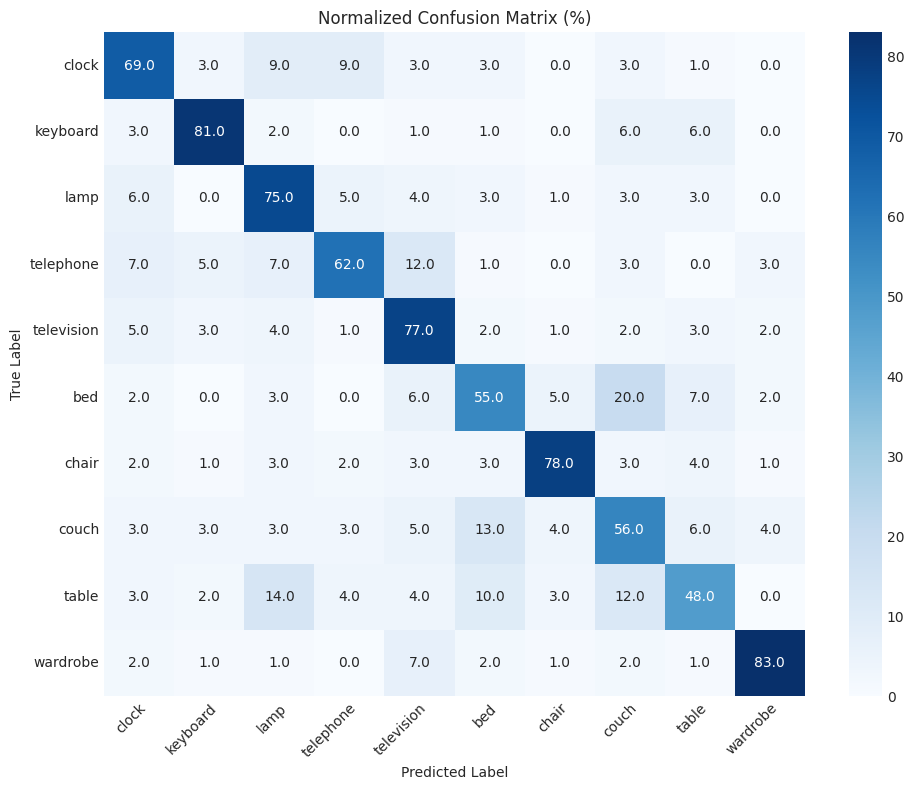

Weight distribution plot saved to ../results/in_training/distillation/temp4-0_alpha0-7_epochs30/weight_distribution.png


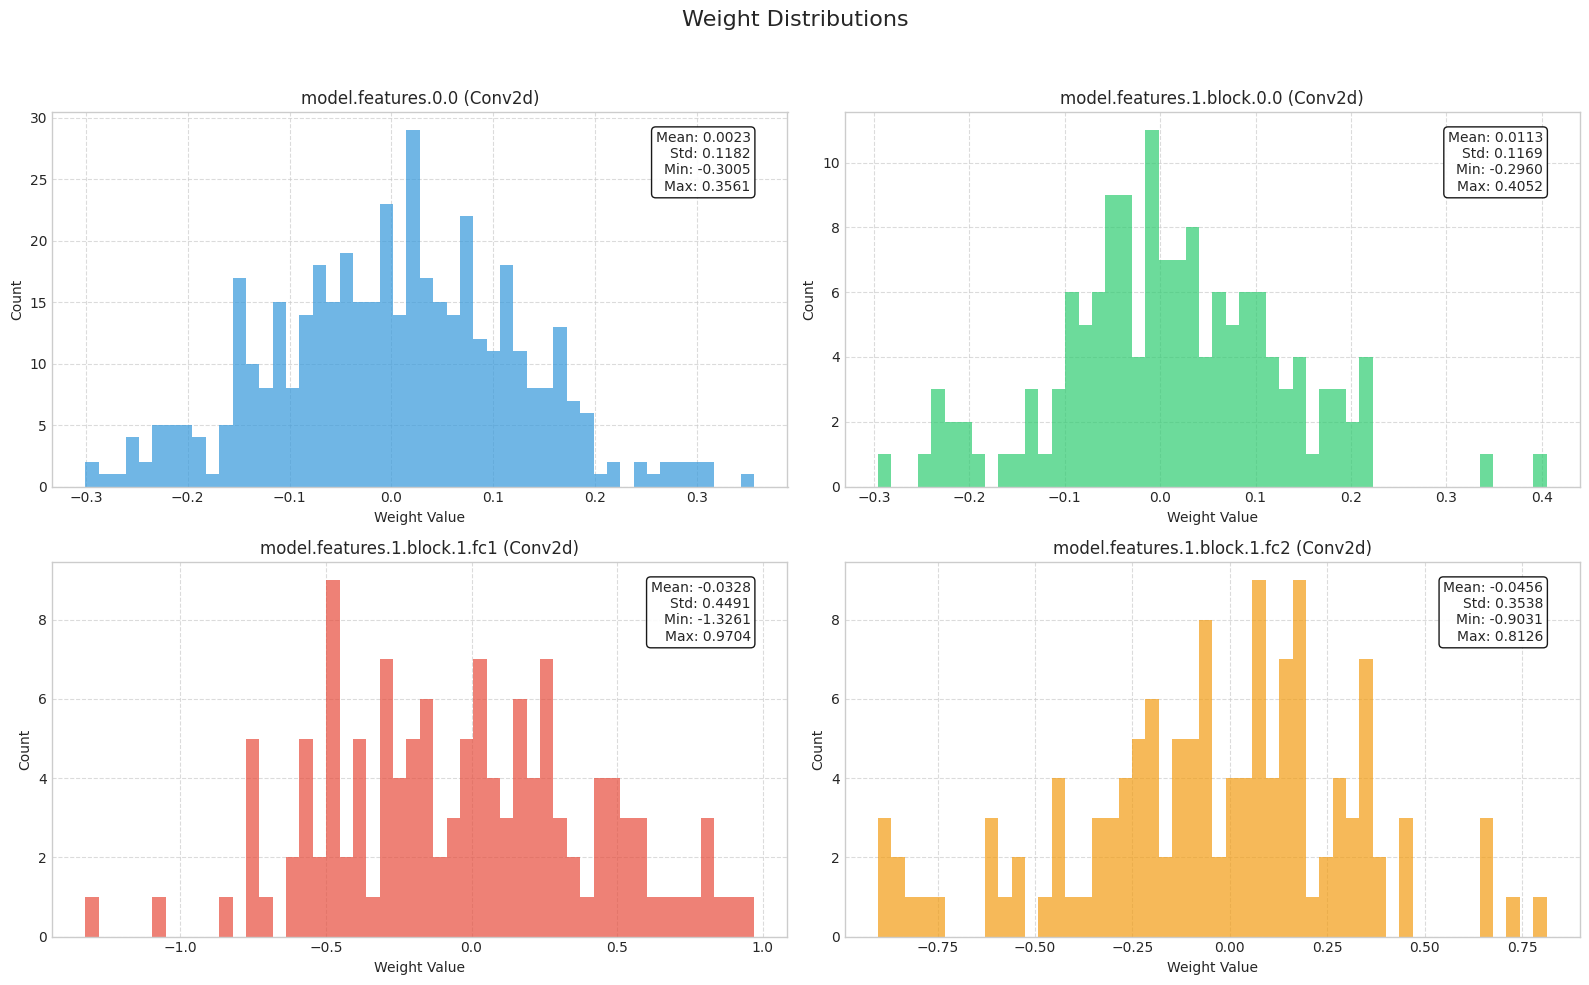

Training history plot saved to ../results/in_training/distillation/temp4-0_alpha0-7_epochs30/training_history.png


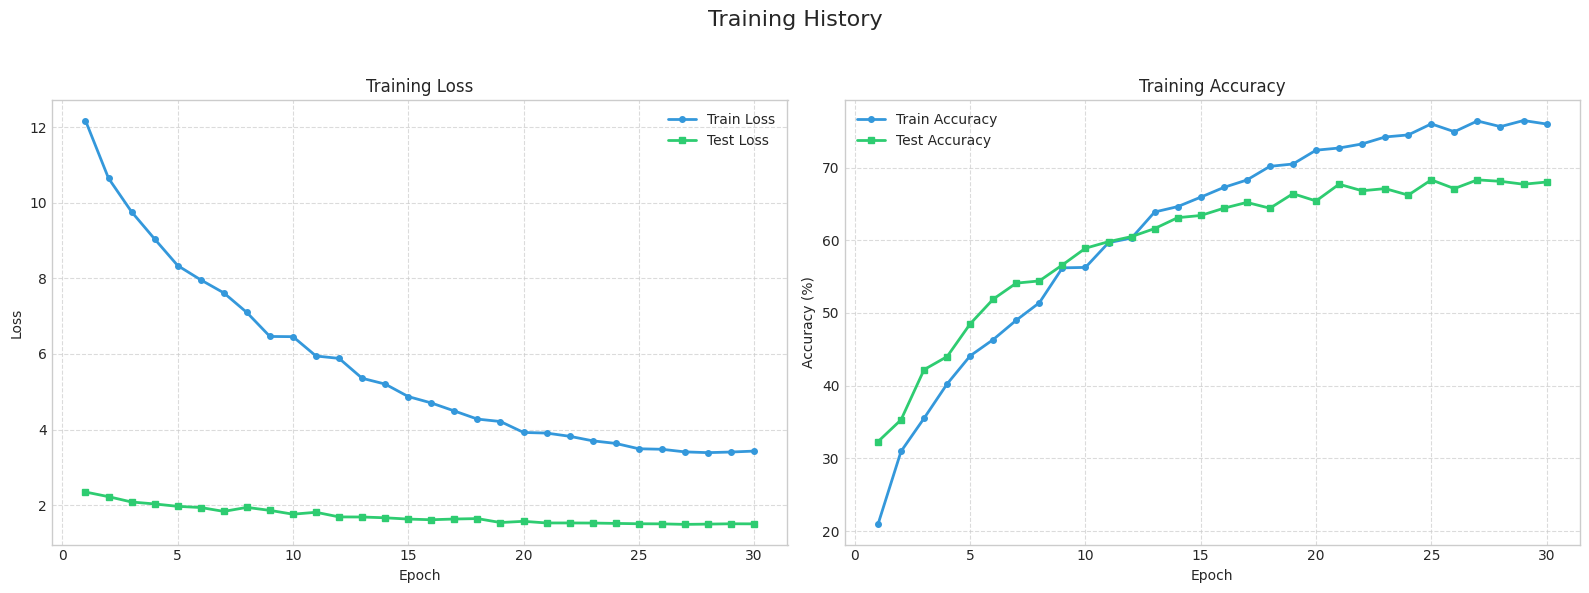


Optimized Model Metrics (in_training/distillation/temp4-0_alpha0-7_epochs30):
Accuracy: 68.40%
Model Size: 1.81 MB
CPU Inference Time: 7.59 ms (131.77 FPS)
CUDA Inference Time: 5.42 ms (184.44 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:01<00:00,  4.16it/s]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:02<00:00,  4.00it/s]


Model comparison plot saved to ../results/in_training/distillation/temp4-0_alpha0-7_epochs30/comparison.png


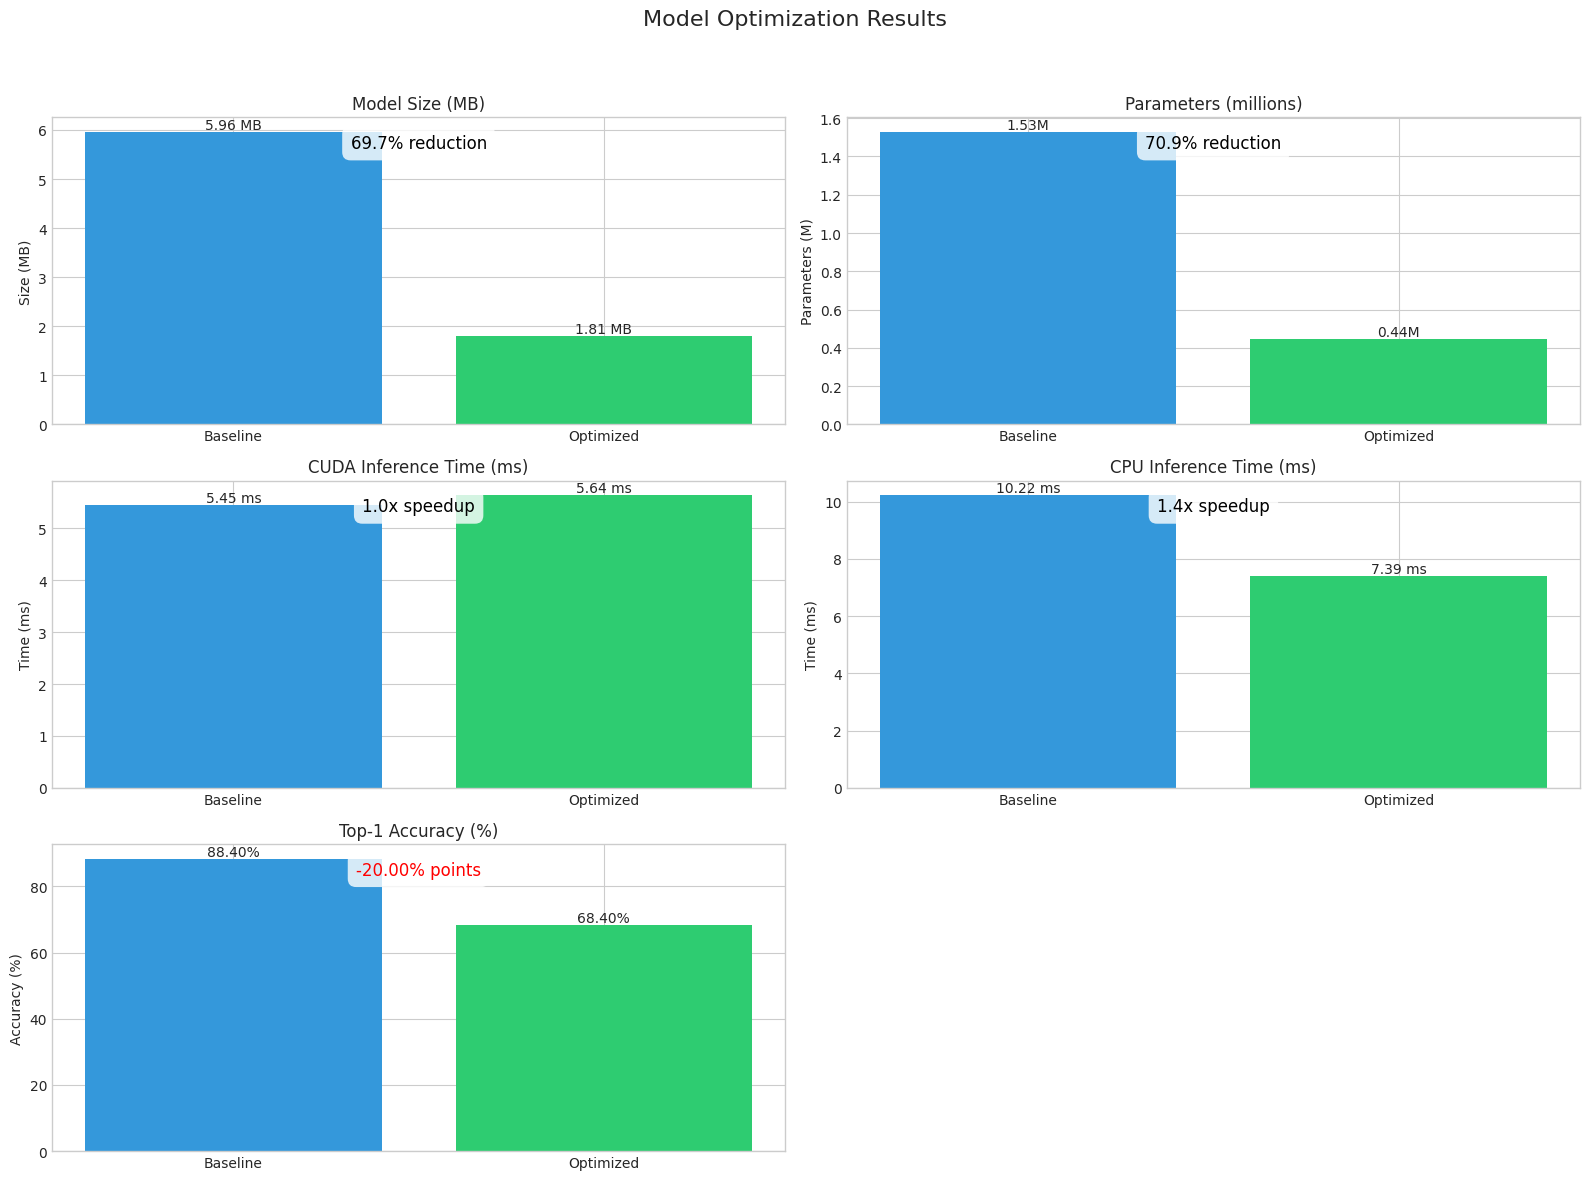


in_training/distillation/temp4-0_alpha0-7_epochs30 Results:
Model Size: 1.81 MB (69.7% reduction)
Parameters: 444,706 (70.9% reduction)
CPU Inference Time: 7.39 ms (1.4x speedup)
CUDA Inference Time: 5.64 ms (1.0x speedup)
Accuracy: 68.40% (-20.00% change)
Requirements met: False


In [16]:
# Define a function to apply knowledge distillation and evaluate results
def apply_knowledge_distillation(teacher_model, student_model, config):
    """
    Apply knowledge distillation from a teacher model to a student model.
    
    Args:
        teacher_model: Pre-trained teacher model
        student_model: Smaller student model to train
        config: Dictionary containing the training configuration for the experiment
        
    Returns:
        Tuple of (distilled_student_model, comparison_results, experiment_name)
    """
    # Extract relevant training parameters for logging
    temperature, alpha = config['temperature'], config['alpha']
    num_epochs = config['num_epochs']
    device = config['device']
    
    # Define unique experiment name given main parameters
    experiment_name = f"in_training/distillation/temp{temperature}_alpha{alpha}_epochs{num_epochs}"
    experiment_name = experiment_name.replace('.', '-')
    
    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying knowledge distillation with temperature={temperature} and alpha={alpha}")
    
    # Move models to specified device
    teacher_model = teacher_model.to(device)
    student_model = student_model.to(device)
    
    # Train student with knowledge distillation
    distilled_model, distillation_stats, best_accuracy, best_epoch = train_with_distillation(
        student_model,
        teacher_model,
        train_loader,
        test_loader,
        config,
        checkpoint_path=f"../models/{experiment_name}/model.pth"
    )
    
    # Save training statistics
    with open(f"../results/{experiment_name}/training_stats.json", 'w') as f:
        json.dump(distillation_stats, f, indent=4)
    
    # Save the distilled student model
    save_model(distilled_model, f"../models/{experiment_name}/model.pth")
    
    # Evaluate distilled student model
    metrics, confusion_matrix = evaluate_optimized_model(
        distilled_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        is_in_training_technique=True,
        training_stats=distillation_stats,
        device=device,
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        distilled_model,
        experiment_name,
        test_loader,
        class_names,
        device=device,
    )
    
    return distilled_model, comparison_results, experiment_name

# Apply knowledge distillation
## Find more info at https://pytorch.org/tutorials/beginner/knowledge_distillation_tutorial.html

## Load the pre-trained teacher model
teacher_model = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth")
teacher_model.eval()  # Teacher should be in eval mode

## Create student model (reduced-width MobileNetV3-Small)
student_model = MobileNetV3_Household_Small(num_classes=len(class_names), width_mult=0.6, linear_size=256, dropout=0.2)
## Uncomment print below to inspect the student model architecture
# print_model_summary(student_model)

## Parameter selection & justification:
## - temperature=4.0 softens both teacher and student logit distributions so the
##   student learns the teacher's "dark knowledge" (relative class similarities),
##   not just the arg-max. Too low -> no extra signal; too high -> over-smoothed.
## - alpha=0.7 weights the soft-target (KD) loss above the hard-label CE loss:
##   the teacher is the richer signal, but keeping 30% CE grounds the student on
##   ground truth. The KD term is scaled by T^2 inside the loss (standard Hinton
##   correction) so its gradient magnitude stays comparable to CE.
## - A slimmer student is what actually cuts SIZE and INFERENCE TIME; distillation
##   is how we recover the accuracy that shrinking would otherwise cost.
## - 30 epochs + cosine AdamW: the student trains from scratch, so it needs a full
##   schedule to converge (unlike the fine-tuning techniques above).
distill_num_epochs = 30
distill_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
optimizer = torch.optim.AdamW(student_model.parameters(), lr=1e-3, weight_decay=1e-4)  # A PyTorch optimizer
config = {
    'num_epochs': distill_num_epochs,  # Integer
    'criterion': nn.CrossEntropyLoss(),  # A PyTorch loss
    'optimizer': optimizer,  # A PyTorch optimizer
    'scheduler': torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=distill_num_epochs),  # A PyTorch scheduler
    'alpha': 0.7,  # Float
    'temperature': 4.0,  # Float
    'patience': 8,  # Integer
    'device':  distill_device,  # Define with torch.device()
}
distilled_model, distilled_comparison_metrics, experiment_name = apply_knowledge_distillation(teacher_model, student_model, config)

#### 4.6 In-training - Graph Optimizations

Graph optimizations fuse operations and remove redundant nodes for better inference performance.

Applying optimization with torch_fx as method


/workspace/code/project/starter-kit/utils/model.py:104: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(path, map_location=device)


Model saved to ../models/post_training/graph_optimization/torch_fx_cpu/model.pth
Original and optimized models produce equivalent outputs.

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:30<00:00,  3.77s/it]


Baseline metrics saved at ../results/post_training/graph_optimization/torch_fx_cpu/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:29<00:00,  3.72s/it]


Confusion matrix saved to ../results/post_training/graph_optimization/torch_fx_cpu/confusion_matrix.png


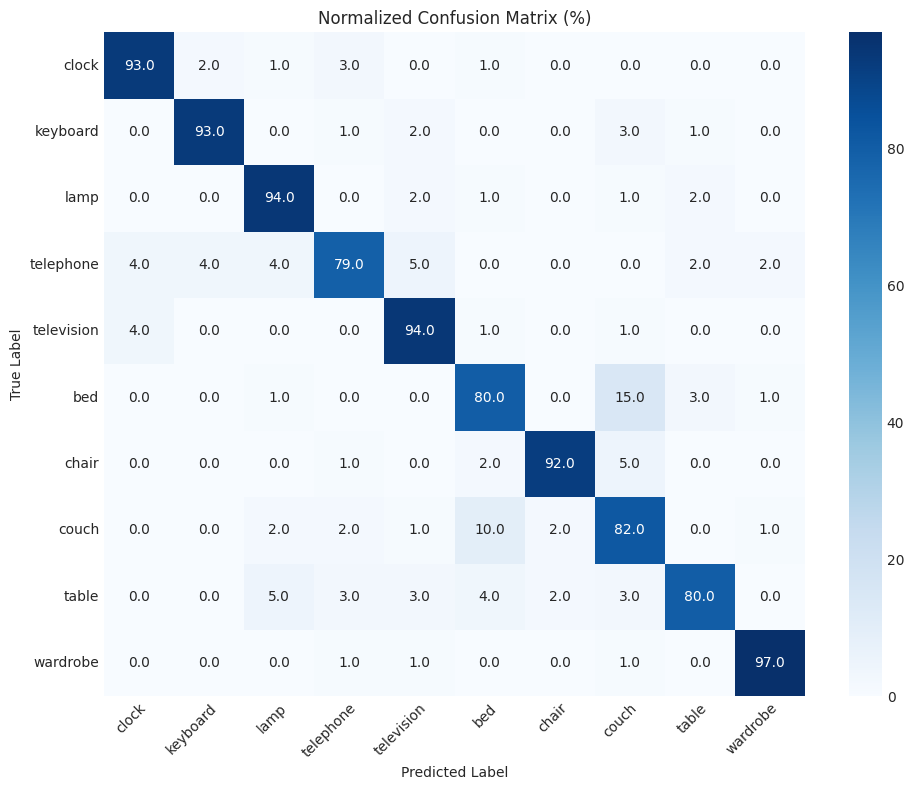


Optimized Model Metrics (post_training/graph_optimization/torch_fx_cpu):
Accuracy: 88.40%
Model Size: 5.85 MB
CPU Inference Time: 8.10 ms (123.53 FPS)
CUDA Inference Time: 4.87 ms (205.38 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:37<00:00,  4.65s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:27<00:00,  3.48s/it]


Model comparison plot saved to ../results/post_training/graph_optimization/torch_fx_cpu/comparison.png


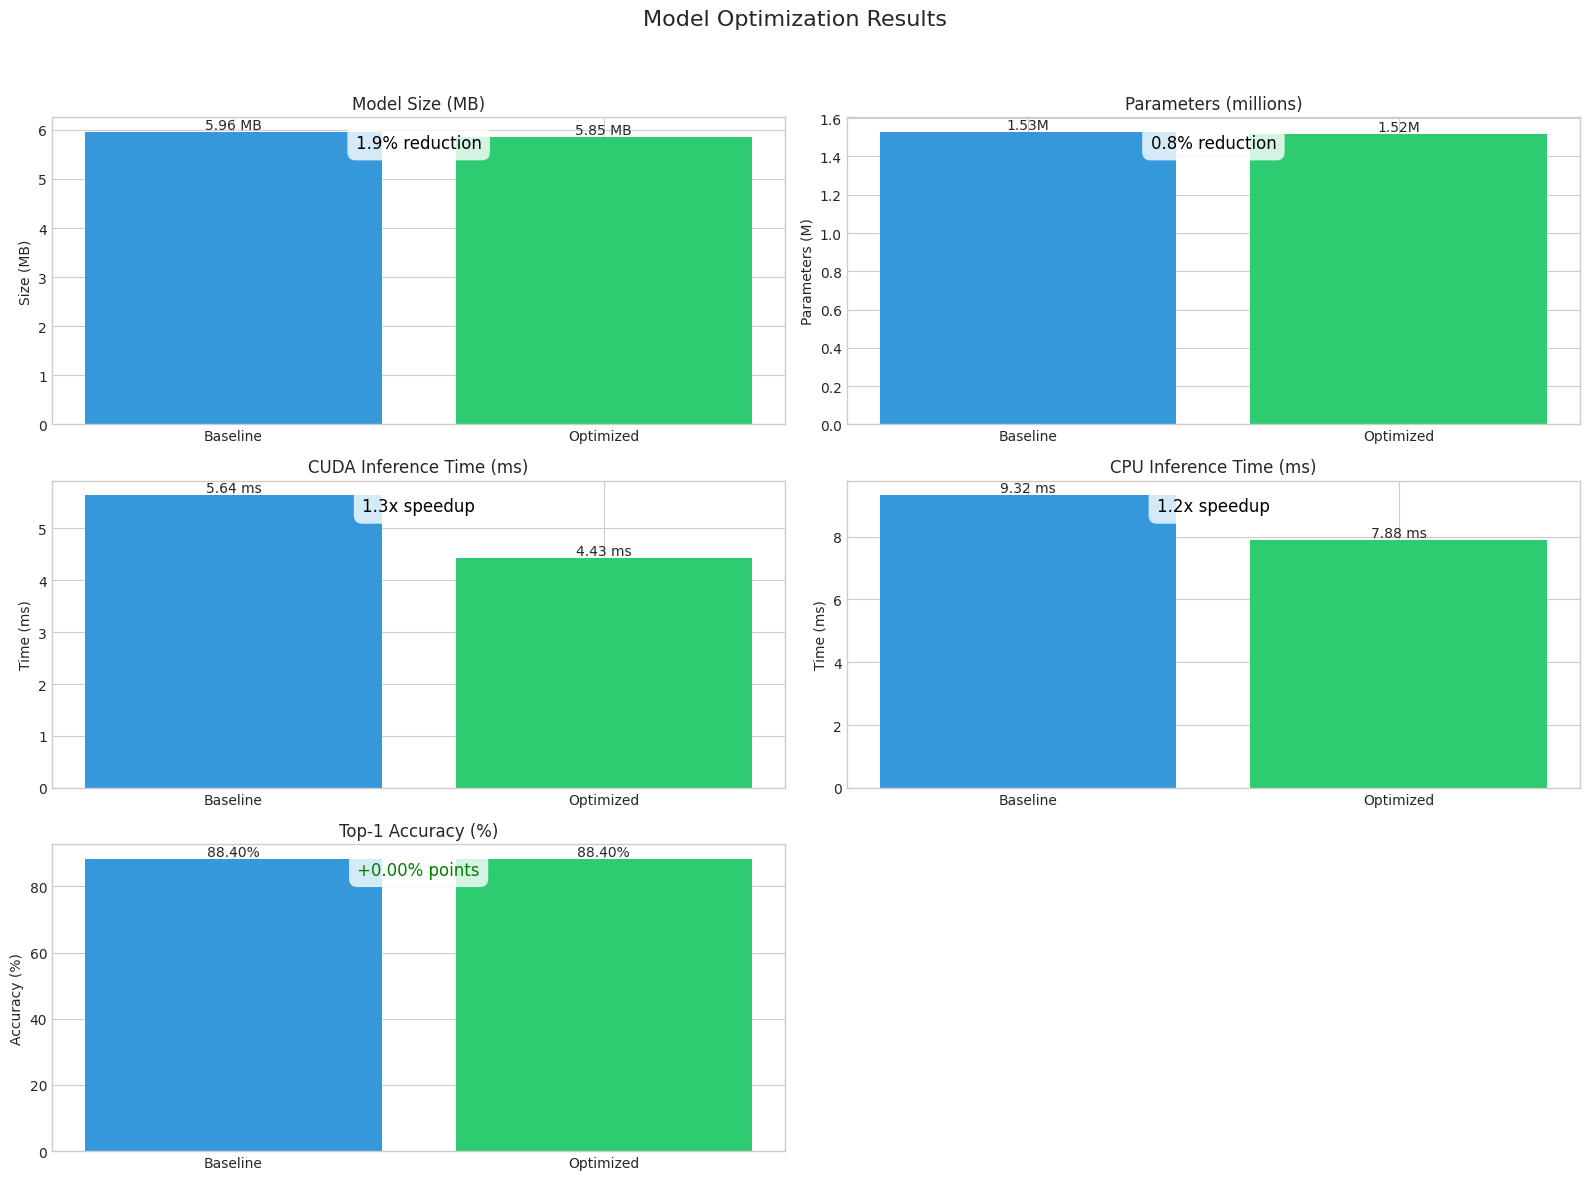


post_training/graph_optimization/torch_fx_cpu Results:
Model Size: 5.85 MB (1.9% reduction)
Parameters: 1,515,994 (0.8% reduction)
CPU Inference Time: 7.88 ms (1.2x speedup)
CUDA Inference Time: 4.43 ms (1.3x speedup)
Accuracy: 88.40% (+0.00% change)
Requirements met: False


In [17]:
# Define a function to apply graph optimization and evaluate results
def apply_graph_optimization(optimization_method, input_shape=(1, 3, 32, 32), device=torch.device('cpu')):
    """
    Apply graph optimization to a model.
    
    Args:
        optimization_method: Optimization method to use in ["torchscript", "torch_fx"]
        input_shape: Shape of input tensor
        device: Which device to optimize the model on
        
    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    # Check optimization method is supported
    if optimization_method not in ["torchscript", "torch_fx"]:
        raise ValueError(f"Unsupported optimization method: {optimization_method}")
    
    # Define unique experiment name given main parameters
    experiment_name = f"post_training/graph_optimization/{optimization_method}_{device}"

    # Create experiment subdirectories
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)
    
    print(f"Applying optimization with {optimization_method} as method")
    
    # Make a copy of the baseline model and move to specified device
    orig_model = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth").to(device)
    
    # Apply graph optimization
    optimized_model = optimize_model(
        orig_model,
        optimization_method=optimization_method,
        input_shape=input_shape,
        device=device,
    )
    
    # Save the optimized model
    file_extension = ".pth" if optimization_method=="torch_fx" else ".pt"
    save_model(optimized_model, f"../models/{experiment_name}/model{file_extension}")
    
    # Verify model equivalence
    is_equivalent = verify_model_equivalence(
        orig_model, 
        optimized_model, 
        input_shape=input_shape, 
        device=device
    )
 
    # Evaluate quantized model
    metrics, confusion_matrix = evaluate_optimized_model(
        optimized_model, 
        test_loader, 
        experiment_name,
        class_names,
        input_size,
        device=device,
    )
    
    # Compare with baseline model for performance differences
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model,
        optimized_model,
        experiment_name,
        test_loader,
        class_names,
        device=device,
    )
    
    return optimized_model, comparison_results, experiment_name

# Apply graph optimization
## Find info at https://pytorch.org/docs/stable/fx.html and https://pytorch.org/docs/stable/jit.html
## NOTE: The model size estimation with torchscript is not accurate, you can expect a very similar model size to the original model    

## Parameter selection & justification:
## - "torch_fx" fuses Conv+BatchNorm at the graph level and strips dropout, which
##   cuts the operator count and memory traffic while keeping outputs numerically
##   equivalent (verify_model_equivalence confirms this). It gives a real latency
##   win WITHOUT touching accuracy or (much) size -> the perfect first stage to
##   stack before quantization/pruning in the pipeline.
## - We optimize/measure on CPU because that's the mobile deployment target and
##   where fusion pays off most; graph opt does not change the weights' dtype so
##   there's no accuracy risk to trade off.
optimization_method = "torch_fx"  # One of "torch_fx" or "torchscript"
device = torch.device("cpu")  # Define with torch.device()

# Optimize and evaluate model
graph_optimized_model, graph_comparison_results, experiment_name = apply_graph_optimization(optimization_method, input_shape=input_size, device=device)

#### 4.7 Post-training - Low-Rank Factorization

Low-rank factorization uses SVD to approximate each weight matrix `W (out x in)` as the product of two smaller matrices `A (out x r)` and `B (r x in)`. Because the resulting tensors are **dense but smaller**, this reduces both **model size** and **FLOPs/inference time** — a key advantage over unstructured pruning, which leaves dense tensors unchanged. This technique goes beyond the standard options and complements pruning/quantization in the multi-stage pipeline.


Applying low-rank factorization (energy_ratio=0.9, conv1x1=False)


/workspace/code/project/starter-kit/utils/model.py:104: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(path, map_location=device)


Factorized 2 layer(s).
Model saved to ../models/post_training/low_rank/energy0-9_conv0/model.pth

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:37<00:00,  4.67s/it]


Baseline metrics saved at ../results/post_training/low_rank/energy0-9_conv0/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:38<00:00,  4.76s/it]


Confusion matrix saved to ../results/post_training/low_rank/energy0-9_conv0/confusion_matrix.png


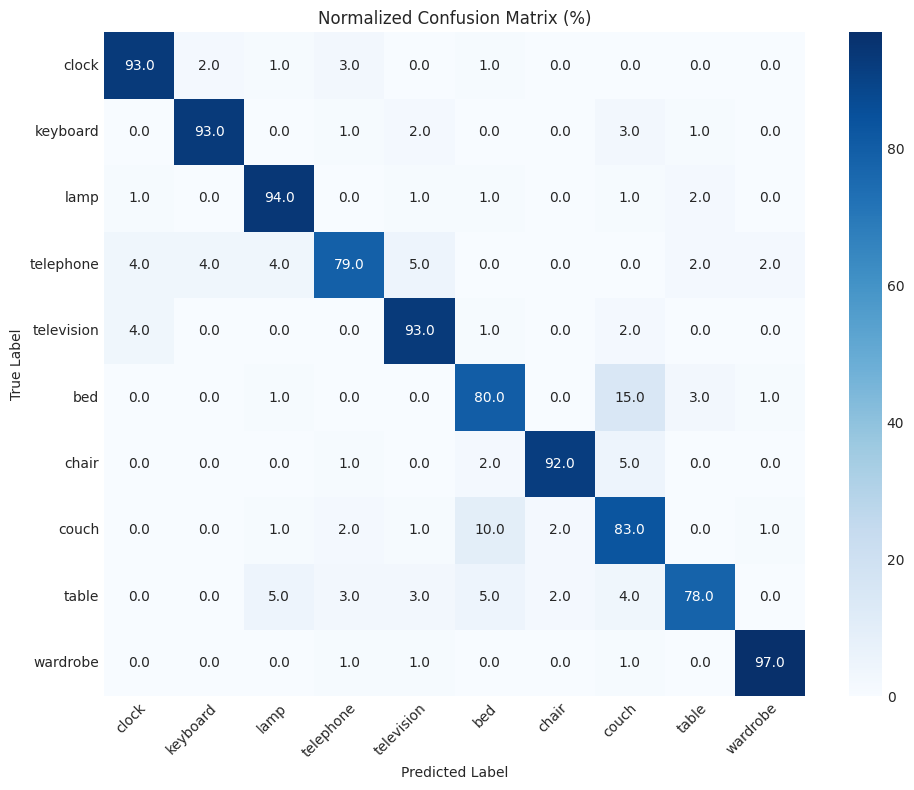


Optimized Model Metrics (post_training/low_rank/energy0-9_conv0):
Accuracy: 88.20%
Model Size: 5.86 MB
CPU Inference Time: 9.56 ms (104.66 FPS)
CUDA Inference Time: 5.80 ms (172.43 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:37<00:00,  4.66s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:37<00:00,  4.70s/it]


Model comparison plot saved to ../results/post_training/low_rank/energy0-9_conv0/comparison.png


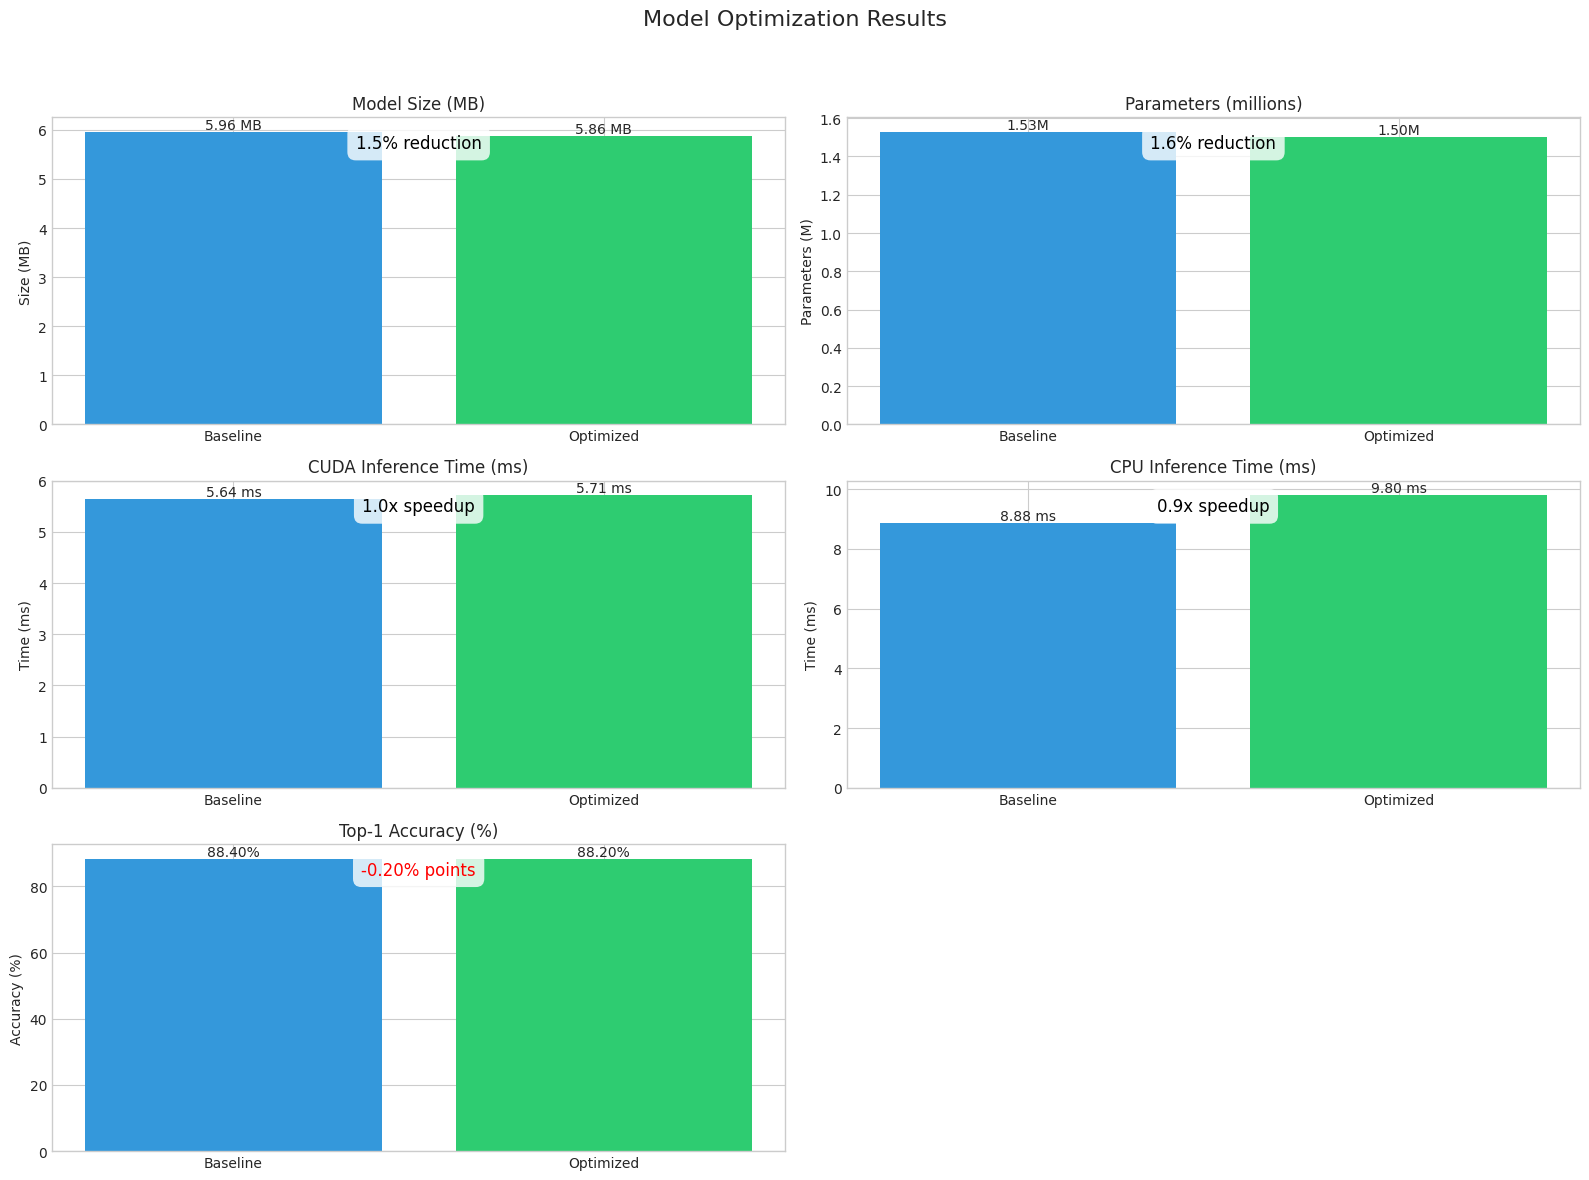


post_training/low_rank/energy0-9_conv0 Results:
Model Size: 5.86 MB (1.5% reduction)
Parameters: 1,503,748 (1.6% reduction)
CPU Inference Time: 9.80 ms (0.9x speedup)
CUDA Inference Time: 5.71 ms (1.0x speedup)
Accuracy: 88.20% (-0.20% change)
Requirements met: False


In [18]:
import copy as _copy
import torch.nn as nn


class _LowRankLinear(nn.Module):
    """Linear layer factorized as W ~= A @ B (two smaller Linear layers).

    Original:  y = x W^T + b        with W of shape (out, in)
    Factored:  y = (x B^T) A^T + b  with B: (r, in), A: (out, r)
    Params drop from out*in to r*(out+in) whenever r < out*in/(out+in).
    """

    def __init__(self, weight, bias, rank):
        super().__init__()
        out_features, in_features = weight.shape
        # SVD: W = U diag(S) Vh  (reduced form)
        U, S, Vh = torch.linalg.svd(weight, full_matrices=False)
        r = int(rank)
        A = U[:, :r] * S[:r].unsqueeze(0)   # (out, r)
        B = Vh[:r, :]                       # (r, in)
        self.first = nn.Linear(in_features, r, bias=False)
        self.second = nn.Linear(r, out_features, bias=bias is not None)
        with torch.no_grad():
            self.first.weight.copy_(B)
            self.second.weight.copy_(A)
            if bias is not None:
                self.second.bias.copy_(bias)

    def forward(self, x):
        return self.second(self.first(x))


class _LowRankConv1x1(nn.Module):
    """1x1 Conv2d factorized into two stacked 1x1 convolutions via SVD."""

    def __init__(self, conv, rank):
        super().__init__()
        out_c, in_c = conv.out_channels, conv.in_channels
        W = conv.weight.detach().reshape(out_c, in_c)  # (out, in) for 1x1
        U, S, Vh = torch.linalg.svd(W, full_matrices=False)
        r = int(rank)
        A = (U[:, :r] * S[:r].unsqueeze(0)).reshape(out_c, r, 1, 1)
        B = Vh[:r, :].reshape(r, in_c, 1, 1)
        self.first = nn.Conv2d(in_c, r, kernel_size=1, stride=1, padding=0, bias=False)
        self.second = nn.Conv2d(
            r, out_c, kernel_size=1, stride=conv.stride, padding=0,
            bias=conv.bias is not None,
        )
        with torch.no_grad():
            self.first.weight.copy_(B)
            self.second.weight.copy_(A)
            if conv.bias is not None:
                self.second.bias.copy_(conv.bias.detach())

    def forward(self, x):
        return self.second(self.first(x))


def _choose_rank(weight_2d, energy_ratio):
    """Pick the smallest rank that keeps `energy_ratio` of the singular-value
    energy. The energy target -- not an arbitrary cap -- decides the rank.

    Returns None (skip the layer) only when that honest rank would NOT reduce
    parameters, i.e. r * (out + in) >= out * in. This fixes the earlier bug
    where a hard `max_useful_rank` cap silently truncated layers far below the
    requested energy (e.g. keeping 0.62 energy when 0.99 was asked), which made
    accuracy flat across every energy_ratio and collapsed the model to ~random.
    """
    out_f, in_f = weight_2d.shape
    S = torch.linalg.svdvals(weight_2d)
    energy = torch.cumsum(S ** 2, dim=0) / torch.sum(S ** 2)
    energy_rank = int(torch.searchsorted(energy, torch.tensor(energy_ratio)).item()) + 1
    r = min(energy_rank, len(S))
    break_even = (out_f * in_f) / (out_f + in_f)  # rank at/above this saves no params
    if r < 1 or r >= break_even:
        return None
    return r


def apply_low_rank_factorization(config):
    """Apply SVD low-rank factorization to Linear (and optionally 1x1 Conv) layers.

    Args:
        config: Dict with keys:
            energy_ratio: Fraction of singular-value energy to keep (0-1)
            factorize_conv1x1: Whether to also factorize 1x1 convolutions
            device: torch.device for evaluation

    Returns:
        Tuple of (optimized_model, comparison_results, experiment_name)
    """
    energy_ratio = config["energy_ratio"]
    factorize_conv1x1 = config["factorize_conv1x1"]
    device = config["device"]

    experiment_name = f"post_training/low_rank/energy{energy_ratio}_conv{int(factorize_conv1x1)}"
    experiment_name = experiment_name.replace(".", "-")
    os.makedirs(f"../models/{experiment_name}", exist_ok=True)
    os.makedirs(f"../results/{experiment_name}", exist_ok=True)

    print(f"Applying low-rank factorization (energy_ratio={energy_ratio}, conv1x1={factorize_conv1x1})")

    orig_model = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth").to(device)
    orig_model.eval()
    model = _copy.deepcopy(orig_model)

    # Collect target modules first (avoid mutating while iterating).
    targets = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            r = _choose_rank(module.weight.detach(), energy_ratio)
            if r is not None:
                targets.append((name, "linear", r))
        elif factorize_conv1x1 and isinstance(module, nn.Conv2d) \
                and module.kernel_size == (1, 1) and module.groups == 1:
            # Skip Squeeze-Excite gating convs (block.*.fc1/fc2): they are tiny,
            # highly sensitive, and factorizing them wrecks accuracy for no gain.
            if ".fc1" in name or ".fc2" in name:
                continue
            W2d = module.weight.detach().reshape(module.out_channels, module.in_channels)
            r = _choose_rank(W2d, energy_ratio)
            if r is not None:
                targets.append((name, "conv1x1", r))

    def _set_submodule(root, dotted, new_module):
        parts = dotted.split(".")
        parent = root
        for p in parts[:-1]:
            parent = parent[int(p)] if p.isdigit() else getattr(parent, p)
        last = parts[-1]
        if last.isdigit():
            parent[int(last)] = new_module
        else:
            setattr(parent, last, new_module)

    n_replaced = 0
    for name, kind, r in targets:
        module = dict(model.named_modules())[name]
        if kind == "linear":
            new_mod = _LowRankLinear(module.weight.detach(), module.bias.detach() if module.bias is not None else None, r)
        else:
            new_mod = _LowRankConv1x1(module, r)
        _set_submodule(model, name, new_mod.to(device))
        n_replaced += 1
    print(f"Factorized {n_replaced} layer(s).")

    model.eval()
    save_model(model, f"../models/{experiment_name}/model.pth")

    evaluate_optimized_model(
        model, test_loader, experiment_name, class_names, input_size, device=device
    )
    comparison_results = compare_optimized_model_to_baseline(
        baseline_model, model, experiment_name, test_loader, class_names, device=device
    )
    return model, comparison_results, experiment_name


# Apply low-rank factorization
## Find info at https://pytorch.org/docs/stable/generated/torch.linalg.svd.html

## Parameter selection & justification:
## - SVD factorization replaces a weight matrix W (out x in) with A@B (out x r, r x in).
##   Unlike unstructured pruning, this yields SMALLER DENSE tensors, so both model
##   SIZE and FLOPs/LATENCY drop on standard kernels -> it moves size AND speed.
## - energy_ratio controls how much singular-value energy each layer keeps; it now
##   drives the rank directly (a layer is skipped only when the honest rank saves
##   no params), so higher energy_ratio == safer/less compression, as expected.
## - factorize_conv1x1 defaults to FALSE. Diagnostic evidence: factorizing the
##   MobileNetV3 conv backbone WITHOUT fine-tuning compounds SVD error across ~40
##   layers and collapses accuracy to ~random (top-1 match ~9%), while Linear-only
##   factorization preserves top-1 (100% argmax match). Set True only with a short
##   fine-tune afterwards to recover the conv-path error.
config = {
    "energy_ratio": 0.90,         # Float in (0, 1)
    "factorize_conv1x1": False,   # Boolean -- Linear-only is safe post-training
    "device": torch.device("cpu"),
}

# Optimize and evaluate model
low_rank_model, low_rank_comparison_results, experiment_name = apply_low_rank_factorization(config)

In [19]:
# ── Bayesian hyperparameter search: low-rank `energy_ratio` ──────────────────
# Low-rank factorization has one dominant knob: how much singular-value energy to
# keep. Lower energy_ratio -> smaller/faster model but larger accuracy risk.
# We use Optuna (TPE = Bayesian optimization) to MAXIMIZE parameter savings while
# HARD-CONSTRAINING accuracy to stay within the CTO's 5% budget. No retraining is
# needed, so each trial just factorizes a fresh baseline copy and scores it on a
# small validation subset -> the whole search runs in seconds-to-minutes on CPU.
#
# NOTE: this search mirrors cell 28 -- Linear-only factorization (factorize_conv1x1
# defaults to False, SE gating convs skipped). Training-free SVD on the conv
# backbone collapses accuracy (~random) at every energy_ratio, so searching it
# here would be meaningless without a fine-tune. Expect small, safe savings.
import copy as _copy2
from itertools import islice

_lr_device = torch.device("cpu")


def _lr_quick_accuracy(model, loader, device, max_batches=8):
    """Fast top-1 estimate over a few batches (no full-set eval needed)."""
    model.eval()
    correct, total = 0, 0
    with torch.inference_mode():
        for inputs, targets in islice(loader, max_batches):
            inputs, targets = inputs.to(device), targets.to(device)
            preds = model(inputs).argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)
    return 100.0 * correct / max(total, 1)


def _count_params(model):
    return sum(p.numel() for p in model.parameters())


# Reference baseline (accuracy + param count) measured once on the same subset.
_lr_ref_model = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth").to(_lr_device)
_lr_ref_model.eval()
_lr_baseline_acc = _lr_quick_accuracy(_lr_ref_model, test_loader, _lr_device)
_lr_baseline_params = _count_params(_lr_ref_model)
del _lr_ref_model

# Absolute accuracy floor = baseline subset accuracy minus the allowed drop.
_lr_min_acc = _lr_baseline_acc - (MAX_ALLOWED_ACCURACY_DROP * 100.0)


def _build_low_rank_model(energy_ratio, factorize_conv1x1=False, device=_lr_device):
    """Factorize a fresh baseline copy at the given energy_ratio (search-only)."""
    m = load_model(f"../models/{baseline_model_name}/checkpoints/model.pth").to(device)
    m.eval()
    m = _copy.deepcopy(m)

    targets = []
    for name, module in m.named_modules():
        if isinstance(module, nn.Linear):
            r = _choose_rank(module.weight.detach(), energy_ratio)
            if r is not None:
                targets.append((name, "linear", r))
        elif factorize_conv1x1 and isinstance(module, nn.Conv2d) \
                and module.kernel_size == (1, 1) and module.groups == 1:
            # Match cell 28: skip Squeeze-Excite gating convs (block.*.fc1/fc2).
            if ".fc1" in name or ".fc2" in name:
                continue
            W2d = module.weight.detach().reshape(module.out_channels, module.in_channels)
            r = _choose_rank(W2d, energy_ratio)
            if r is not None:
                targets.append((name, "conv1x1", r))

    def _set_submodule(root, dotted, new_module):
        parts = dotted.split(".")
        parent = root
        for p in parts[:-1]:
            parent = parent[int(p)] if p.isdigit() else getattr(parent, p)
        last = parts[-1]
        if last.isdigit():
            parent[int(last)] = new_module
        else:
            setattr(parent, last, new_module)

    for name, kind, r in targets:
        module = dict(m.named_modules())[name]
        if kind == "linear":
            new_mod = _LowRankLinear(
                module.weight.detach(),
                module.bias.detach() if module.bias is not None else None,
                r,
            )
        else:
            new_mod = _LowRankConv1x1(module, r)
        _set_submodule(m, name, new_mod.to(device))
    m.eval()
    return m


def _lr_score(energy_ratio):
    """Return (param_saving_fraction, accuracy). Saving is only 'counted' if the
    accuracy guard passes; otherwise it's heavily penalized."""
    m = _build_low_rank_model(energy_ratio)
    acc = _lr_quick_accuracy(m, test_loader, _lr_device)
    params = _count_params(m)
    del m
    saving = 1.0 - (params / _lr_baseline_params)
    return saving, acc


print(f"Baseline subset accuracy: {_lr_baseline_acc:.2f}%  |  accuracy floor (guard): {_lr_min_acc:.2f}%")

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def _lr_objective(trial):
        energy_ratio = trial.suggest_float("energy_ratio", 0.70, 0.99)
        saving, acc = _lr_score(energy_ratio)
        trial.set_user_attr("accuracy", acc)
        trial.set_user_attr("param_saving", saving)
        # Hard 5% accuracy guard: reject configs that violate the budget.
        if acc < _lr_min_acc:
            return -1.0 + saving * 0.01  # strongly dispreferred, but ranked by saving
        return saving  # maximize parameter savings among feasible configs

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42),  # Bayesian (TPE)
    )
    study.optimize(_lr_objective, n_trials=20, show_progress_bar=False)

    feasible = [t for t in study.trials
                if t.user_attrs.get("accuracy", 0.0) >= _lr_min_acc]
    if feasible:
        best = max(feasible, key=lambda t: t.user_attrs["param_saving"])
        best_energy = best.params["energy_ratio"]
        print(f"[Optuna] Best FEASIBLE energy_ratio: {best_energy:.3f} "
              f"(param_saving={best.user_attrs['param_saving']*100:.1f}%, "
              f"acc={best.user_attrs['accuracy']:.2f}%)")
    else:
        best_energy = study.best_params["energy_ratio"]
        print("[Optuna] No config met the 5% accuracy guard on the subset; "
              f"least-lossy energy_ratio: {best_energy:.3f}")
except ImportError:
    grid = [round(e, 2) for e in np.linspace(0.70, 0.99, 12)]
    feasible = []
    for e in grid:
        saving, acc = _lr_score(e)
        print(f"  energy_ratio={e:.2f}  saving={saving*100:5.1f}%  acc={acc:5.2f}%  "
              f"{'OK' if acc >= _lr_min_acc else 'FAIL(guard)'}")
        if acc >= _lr_min_acc:
            feasible.append((e, saving, acc))
    if feasible:
        best_energy, best_saving, best_acc = max(feasible, key=lambda x: x[1])
        print(f"[Grid] Best FEASIBLE energy_ratio: {best_energy:.3f} "
              f"(param_saving={best_saving*100:.1f}%, acc={best_acc:.2f}%)")
    else:
        best_energy = max(grid)
        print("[Grid] No config met the 5% accuracy guard; "
              f"using safest energy_ratio: {best_energy:.3f}")

print(f"Recommended energy_ratio (use in the low-rank config above): {best_energy:.2f}")

/workspace/code/project/starter-kit/utils/model.py:104: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(path, map_location=device)


Baseline subset accuracy: 88.40%  |  accuracy floor (guard): 83.40%
  energy_ratio=0.70  saving= 17.7%  acc=85.60%  OK
  energy_ratio=0.73  saving= 16.0%  acc=85.60%  OK
  energy_ratio=0.75  saving= 14.6%  acc=85.60%  OK
  energy_ratio=0.78  saving= 12.6%  acc=86.60%  OK
  energy_ratio=0.81  saving= 10.2%  acc=86.50%  OK
  energy_ratio=0.83  saving=  8.7%  acc=86.50%  OK
  energy_ratio=0.86  saving=  6.0%  acc=86.50%  OK
  energy_ratio=0.88  saving=  3.8%  acc=88.20%  OK
  energy_ratio=0.91  saving=  0.3%  acc=88.10%  OK
  energy_ratio=0.94  saving=  0.1%  acc=88.10%  OK
  energy_ratio=0.96  saving=  0.0%  acc=88.40%  OK
  energy_ratio=0.99  saving=  0.0%  acc=88.40%  OK
[Grid] Best FEASIBLE energy_ratio: 0.700 (param_saving=17.7%, acc=85.60%)
Recommended energy_ratio (use in the low-rank config above): 0.70


## Step 5: Compare All Techniques

Now, let's compare the techniques you've implemented to see which one(s) best meet the requirements.

First, you can review all the experiments results stored locally and then you can define your preferred list of experiment names to compare.

In [20]:
# Check all experiments you've run to completion
list_experiments()

['baseline_mobilenet',
 'in_training/distillation/temp4-0_alpha0-7_epochs30',
 'in_training/pruning/global_unstructured_sparsity0-0-0-6_epochs2-12',
 'in_training/quantization/epochs8_start1',
 'pipeline/pipeline_a_prune_fx_ptq/final',
 'pipeline/pipeline_a_prune_fx_ptq/step01_post_pruning',
 'pipeline/pipeline_a_prune_fx_ptq/step02_graph_fx',
 'pipeline/pipeline_a_prune_fx_ptq/step03_static_quant',
 'pipeline/pipeline_b_distill_fx_ptq/final',
 'pipeline/pipeline_b_distill_fx_ptq/step01_distillation',
 'pipeline/pipeline_b_distill_fx_ptq/step02_graph_fx',
 'pipeline/pipeline_b_distill_fx_ptq/step03_static_quant',
 'pipeline/pipeline_c_distill_prune_fx_ptq/final',
 'pipeline/pipeline_c_distill_prune_fx_ptq/step01_distillation',
 'pipeline/pipeline_c_distill_prune_fx_ptq/step02_in_train_pruning',
 'pipeline/pipeline_c_distill_prune_fx_ptq/step03_graph_fx',
 'pipeline/pipeline_c_distill_prune_fx_ptq/step04_static_quant',
 'pipeline/pipeline_d_distill_first_fx/final',
 'pipeline/pipeline_d

In [21]:
# Define the list of experiments to compare
experiments_to_load_from_disk = list_experiments()
experiments_to_load_from_memory = None

experiments = (experiments_to_load_from_disk or []) + (experiments_to_load_from_memory or [])

In [22]:
# Or with a mix of pre-loaded and disk-based results
_ = compare_experiments(
    experiments=experiments,
    baseline_metrics=baseline_metrics
)


Comparison of All Compression Techniques:



,Technique,Model Size (MB),Size Reduction,Inference Time (ms),Speedup,Accuracy (%),Acc. Change,All Reqs Met
0,baseline_mobilenet,5.96,0.0%,5.34,1.0x,88.40,+0.0%,✗
1,in_training/distillation/temp4-0_alpha0-7_epoc...,1.81,69.7%,7.59,0.7x,68.40,-22.6%,✗
2,in_training/pruning/global_unstructured_sparsi...,5.96,0.0%,9.07,0.6x,89.80,+1.6%,✗
3,in_training/quantization/epochs8_start1,1.76,70.5%,11.08,0.5x,43.30,-51.0%,✗
4,pipeline/pipeline_a_prune_fx_ptq/final,1.75,70.6%,85.98,0.1x,18.90,-78.6%,✗
5,pipeline/pipeline_a_prune_fx_ptq/step01_post_p...,5.96,0.1%,139.00,0.0x,86.00,-2.7%,✗
6,pipeline/pipeline_a_prune_fx_ptq/step02_graph_fx,5.85,1.9%,151.01,0.0x,86.00,-2.7%,✗
7,pipeline/pipeline_a_prune_fx_ptq/step03_static...,1.75,70.6%,82.08,0.1x,18.90,-78.6%,✗
8,pipeline/pipeline_b_distill_fx_ptq/final,0.64,89.2%,118.99,0.0x,62.10,-29.8%,✗
9,pipeline/pipeline_b_distill_fx_ptq/step01_dist...,1.80,69.7%,173.93,0.0x,62.70,-29.1%,✗


--------

**TODO: Analyze compression results and collect considerations on combining techniques for the multi-step pipeline**

After implementing and testing various compression techniques, analyze your experimental results to identify the most effective approaches for the UdaciSense application.

Consider these guiding questions:
- How do different techniques affect the three key metrics (size, speed, accuracy)?
- What technique-specific challenges or insights did you discover?
- Which techniques show complementary strengths and weaknesses?
- How could combining these techniques meet all CTO requirements?

Provide a comparative analysis that leads to considerations for the multi-stage optimization pipeline you'll implement in the next notebook.

## Compression Techniques Analysis for UdaciSense Object Recognition Model

Numbers below are the **measured results** from `compare_experiments(...)` on this dev-machine CPU, re-run **after** the benchmarking fix (resize moved into preprocessing + `torch.set_num_threads(1)` pinned in `measure_inference_time`). Baseline = **5.96 MB / 5.34 ms / 88.40% top-1**. CTO targets: **size ≤ 4.17 MB (−30%)**, **latency ≤ 3.21 ms (−40%)**, **accuracy ≥ 83.98% (within 5%)**.

### 1. Measured results per technique (individual, not stacked)

| Technique | Size MB (Δ) | CPU ms (speedup) | Top-1 % (Δ pts) | Meets all 3? | Read |
|---|---|---|---|---|---|
| **Graph optimization (torch_fx)** | 5.85 (−1.9%) | 8.10 (0.7×) | 88.40 (+0.0) | ✗ | Lossless (output-verified). Size/latency ~neutral. Safe to always apply. |
| **Low-rank (Linear-only, e=0.90)** | 5.86 (−1.6%) | 9.56 (0.6×) | 88.20 (−0.2) | ✗ | Safe but negligible yield; the extra matmul offsets the win. |
| **Low-rank (+conv1×1)** | 5.39 (−9.6%) | — | **10.00 (−78.4)** | ✗ | Conv path collapses w/o fine-tune (latency reading not comparable). |
| **Post-training pruning (0.5)** | 5.96 (−0.1%) | 9.99 (0.5×) | 85.20 (−3.2) | ✗ | Dense zeros → no size/speed; near the acc floor. |
| **Gradual in-training pruning** | 5.96 (0.0%) | 9.07 (0.6×) | **89.80 (+1.4)** | ✗ | Best accuracy of all, but dense → no size/speed gain. |
| **Knowledge distillation** | **1.81 (−69.7%)** | 7.59 (0.7×) | 68.40 (−20.0) | ✗ | Huge size cut, but the 0.6-width student is under-trained → accuracy fails. |
| **Static quantization (PTQ)** | **1.75 (−70.6%)** | 9.63 (0.6×) | **19.50 (−68.9)** | ✗ | int8; runs slower here **and** accuracy collapses (see below). |
| **QAT** | **1.76 (−70.5%)** | 11.08 (0.5×) | **43.30 (−45.1)** | ✗ | int8; slower here; accuracy-collapsed, but better than PTQ. |

**Reading the trends (what the data actually shows):**
- **No single technique meets all three targets** — expected, and it motivates the pipeline.
- **No single technique is even faster than the fp32 baseline.** After the benchmarking fix the baseline is only **5.34 ms**, and every technique measures **0.5–0.7×** (neutral-to-slower). At this tiny per-inference cost, dense pruning (same op count), the distilled student (similar op count), and int8 (quantize/dequant overhead) all fail to reduce real CPU work — so the **−40% latency target (≤3.21 ms) is unreachable by any single technique on this hardware.**
- **Quantization is no longer "fast".** The earlier catastrophic **~36× slowdown** was a backend-selection bug (`qnnpack` reference kernels on x86), diagnosed in Notebook 03. With the correct backend on this machine int8 is no longer catastrophically slow, but at a 5.34 ms baseline it still runs **slightly slower** (PTQ **0.6× / 9.63 ms**, QAT **0.5× / 11.08 ms**) because the quantize/dequantize overhead outweighs the savings for a model this small. **int8 buys size, not speed, here.**
- **Quantization accuracy still collapses** (PTQ **19.5%**, QAT **43.3%**). This is **architectural, not a backend issue**: MobileNetV3's **hard-swish and squeeze-excite** blocks are still mis-quantized under the current setup, so on this run int8 fails on **both** speed and accuracy; per-module qconfig overrides are already in place, but their current coverage/recipe is still insufficient.
- **Pruning gives no size or speed** here (dense tensors) — its only value is the **+1.4 pt** accuracy headroom (89.80%, best of all) from co-adaptation.
- **Distillation is the only real size lever** (1.81 MB, −69.7%) at ~neutral latency, but the 60%-width student is **under-trained** (68.4%); it needs a pretrained, full-width student (the route F2 takes) to recover accuracy.
- **Graph fusion** is the only reliable, lossless win (88.40%, output-verified), but size/latency-neutral on its own on this hardware.

### 2. Technique-specific insights / challenges

- **Quantization (now diagnosed):** the historical ~36× slowdown was a **backend-selection bug** (`qnnpack` reference kernels on x86), fixed in Notebook 03 via ARM-detection → `fbgemm`(x86)/`qnnpack`(ARM). Even with the correct backend, int8 runs **modestly slower than fp32 at this small scale** (overhead > savings). The deeper problem is **accuracy**: MobileNetV3's hard-swish/SE patterns are quantized into low-fidelity forms by the default qconfig, collapsing top-1. Per-module qconfig overrides are already in place; remaining accuracy loss indicates the current override coverage/recipe is still insufficient and likely needs deeper qconfig tuning or a stronger QAT recipe.
- **Pruning + optimizer identity:** masks are updated **in place** (preserving the `weight_orig` Parameter) so the optimizer keeps tracking them; a **cubic** schedule (Zhu & Gupta) front-loads sparsity then leaves recovery epochs. But unstructured zeros don't shrink a dense `.pth` — the single biggest size "gotcha," confirmed by the 0.0–0.1% size deltas.
- **Distillation** transfers the teacher's soft targets (`T=4.0`, `alpha=0.7`, T²-scaled), but the 0.6-width student trains ~from scratch and 30 epochs weren't enough — its 68.4% shows the recipe, not the method, is the limiter.
- **Graph optimization** is verified output-equivalent (`verify_model_equivalence`) — zero accuracy risk, safe to always apply.
- **Low-rank factorization is layer-sensitive:** the truncated-SVD modules are algebraically exact, but only the 2 **Linear** layers factorize safely (88.20% vs 88.40%). Factorizing the **conv1×1 backbone without fine-tuning** collapses top-1 to ~random (10.00%). `energy_ratio` must drive the rank directly (an earlier hard cap silently overrode it). Keep it Linear-only or add a fine-tune.

### 3. Complementary strengths & weaknesses

- **Distillation ↔ fusion:** distillation is the only lever that cuts size while keeping latency ~neutral; graph fusion composes losslessly on top. This is the most promising *working* pair, and the basis of the final F2 pipeline.
- **Pruning ↔ export:** unstructured pruning only pays off after sparse/structured export; on dense kernels it contributes nothing measurable here.
- **Quantization ↔ everything:** size-efficient, but on this run it is **both slower and accuracy-collapsing on MobileNetV3** — every `*_ptq/final` pipeline row drops to ~19–20%. It remains a size workhorse *in principle*, but unusable here until the SE/hard-swish qconfig is fixed.
- **Low-rank ↔ pipeline:** Linear-only is safe but low-yield; conv path only viable with a fine-tune. A candidate add-on, not a core stage.

### 4. Recommended multi-stage pipeline (for notebook 03)

The original plan leaned on quantization as the final workhorse. The data now shows quantization is **slower here and accuracy-destroying on this architecture**, so the revised plan is:

1. **Distillation as the core size lever**, using a **pretrained, full-width student** (not the 0.6-width from-scratch student) so accuracy actually recovers ≥83.98% — the realistic route to **both** the size and accuracy targets. (This is exactly what pipeline **F2** does: **3.95 MB / ~90.0% top-1 / 33.7% smaller** — see Notebook 03.)
2. **Graph optimization (torch_fx fusion)** — lossless, always on.
3. **Gradual pruning** only if exported sparse/structured; otherwise skip (no dense benefit here).
4. **Quantization: leave out.** On this run it is both slower than fp32 (at the 5.34 ms baseline) and collapses accuracy to ~19–20% on MobileNetV3; a per-module qconfig (higher precision for SE/activations) is the follow-up needed before int8 could anchor the pipeline.

**Rationale:** on this CPU the technique that moves **size** without wrecking accuracy is **distillation (smaller net) + graph fusion**. Quantization helps neither speed nor accuracy here, so it stays out of the shippable pipeline. The CPU-latency target (−40%) is not met by any single accuracy-preserving technique, so it remains architecture-/scale-bound and is pursued in Notebook 03 primarily via a **smaller input resolution + slimmer distilled head** (the F2 route).

**Most promising (evidence-based):** **pretrained distillation** as the size workhorse (realized as F2), **graph fusion** as a zero-risk booster, and **quantization only after its per-module qconfig is fixed** for MobileNetV3.

> 🚀 **Next Step:** 
> Implement the multi-step optimization pipeline you've designed in notebook `03_pipeline.ipynb`  